# import package

In [1]:
import numpy as np
import pandas as pd
import patsy.version
import doubleml as dml
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import math
import patsy 
from causalml.dataset.regression import *
from causalml.metrics import *
import scipy
import random
import tensorflow as tf
import torch

import optuna
from optuna.visualization import plot_optimization_history
import optuna.trial as trial

import contextlib
import io

Failed to import duecredit due to No module named 'duecredit'


# GSNet_R

GSNet_R loss

In [2]:
from tensorflow.keras import Input, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.layers import Dense, Concatenate
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import load_model
from tensorflow.keras import backend as K
from causalml.inference.tf.utils import (
    EpsilonLayer,
    binary_classification_loss,
    treatment_accuracy,
    track_epsilon
)
from causalml.inference.meta.utils import convert_pd_to_np
import tensorflow as tf


def pairwise_squared_distance(x, y):
    x_norm = tf.reduce_sum(tf.square(x), axis=1, keepdims=True)
    y_norm = tf.reduce_sum(tf.square(y), axis=1, keepdims=True)
    dist = (x_norm- 2.0 * tf.matmul(x, y, transpose_b=True)+ tf.transpose(y_norm))
    return tf.maximum(dist, 0.0)


def sinkhorn_distance(x, y, epsilon=0.1, n_iters=50):
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    n = tf.shape(x)[0]
    m = tf.shape(y)[0]

    # Uniform probability masses
    a = tf.ones([n], dtype=tf.float32) / tf.cast(n, tf.float32)
    b = tf.ones([m], dtype=tf.float32) / tf.cast(m, tf.float32)

    # Cost matrix [n, m]
    C = pairwise_squared_distance(x, y)

    # Kernel
    K = tf.exp(-C / epsilon)

    # Avoid numerical problems
    K = tf.maximum(K, 1e-9)

    u = tf.ones_like(a)
    v = tf.ones_like(b)

    for _ in range(n_iters):
        u = a / tf.maximum(tf.linalg.matvec(K, v),1e-9)
        v = b / tf.maximum(tf.linalg.matvec(tf.transpose(K),u),1e-9)

    # Optimal transport plan
    P = tf.expand_dims(u, 1) * K * tf.expand_dims(v, 0)

    # Transport cost
    distance = tf.reduce_sum(P * C)

    return distance

def hsic_loss(z_treatment,z_control,sigma=1.0):

    # Use equal number of samples
    n = tf.minimum(tf.shape(z_treatment)[0],tf.shape(z_control)[0])
    z_treatment = z_treatment[:n]
    z_control = z_control[:n]
    z_treatment = tf.cast(z_treatment, tf.float32)
    z_control = tf.cast(z_control, tf.float32)

    # RBF kernels
    def rbf_kernel(x):
        x_norm = tf.reduce_sum(tf.square(x),axis=1,keepdims=True)
        dist = (x_norm - 2.0 * tf.matmul(x, x, transpose_b=True) + tf.transpose(x_norm))
        dist = tf.maximum(dist, 0.0)
        return tf.exp(-dist / (2.0 * sigma ** 2))

    K_t = rbf_kernel(z_treatment)
    K_c = rbf_kernel(z_control)

    # Centering matrix
    n_float = tf.cast(n, tf.float32)
    H = (tf.eye(n) - tf.ones([n, n], dtype=tf.float32) / n_float)

    # Centered kernels
    K_t_centered = tf.matmul(tf.matmul(H, K_t),H)
    K_c_centered = tf.matmul(tf.matmul(H, K_c),H)

    # HSIC
    hsic = tf.reduce_sum(K_t_centered * K_c_centered) / tf.square(n_float - 1.0)
    return hsic


def binary_useregression_loss(concat_true, concat_pred):
    t_true = concat_true[:, 1]
    t_pred = concat_pred[:, 2]
    t_pred = (t_pred + 0.001) / 1.002
    losst = tf.reduce_sum(tf.square(t_true - t_pred))
    return losst


def regression_loss(concat_true, concat_pred):

    y_true = concat_true[:, 0]
    t_true = concat_true[:, 1]
    y_pred = concat_pred[:, 0]
    loss = tf.reduce_sum(tf.square(y_true - y_pred))
    return loss


def dragonnet_loss_binarycross(concat_true, concat_pred):
    return regression_loss(concat_true, concat_pred) + binary_useregression_loss(concat_true, concat_pred)


def y_binary_classification_loss(concat_true, concat_pred):
    """
    Classification loss on y - used for MNIST causal effect
    """

    y_true = concat_true[:, 0]
    t_true = concat_true[:, 1]

    y_pred = concat_pred[:, 0]
    y1_pred = concat_pred[:, 1]

    try:
        y_pred = (y_pred.numpy() + 0.001) / 1.002
        y_true = y_true.numpy()
        y_true = y_true.astype('float32')
        y_pred = y_pred.astype('float32')
        y_loss = np.sum(K.binary_crossentropy(y_true, y_pred))
    except AttributeError:
        y_pred = (y_pred + 0.001) / 1.002
        # y_true = y_true.numpy()
        # y_true = y_true.astype('float32')
        # y_pred = y_pred.astype('float32')
        y_loss = tf.reduce_sum(K.binary_crossentropy(y_true, y_pred))
    return y_loss


def dragonnet_double_binarycross(concat_true, concat_pred):
    """
    Total Classification loss - used for MNIST causal effect
    """
    return y_binary_classification_loss(concat_true, concat_pred) + binary_classification_loss(concat_true, concat_pred)


def mu_risk_ce_loss(concat_true, concat_pred):
    t_true = concat_true[:, 1]
    t_pred = concat_true[:, 2]

    y_true = concat_true[:, 0]
    y_pred = concat_pred[:, 0]

    loss = tf.reduce_sum(tf.square(y_true - y_pred) * (K.binary_crossentropy(t_true, t_pred)+1+tf.math.log(0.5)))
    return loss

def dragonnet_mu_risk_ce(concat_true, concat_pred, alpha=1.0):
    return mu_risk_ce_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)


def mu_risk_ce_loss_ybinary(concat_true, concat_pred):
    t_true = concat_true[:, 1]
    t_pred = concat_true[:, 2]

    y_true = concat_true[:, 0]
    y_pred = concat_pred[:, 0]
    y_pred = (y_pred + 0.001) / 1.002

    loss = tf.reduce_sum((K.binary_crossentropy(y_true, y_pred)) * (K.binary_crossentropy(t_true, t_pred)+1+tf.math.log(0.5)))
    return loss

def dragonnet_mu_risk_ce_ybinary(concat_true, concat_pred, alpha=1.0):
    return mu_risk_ce_loss_ybinary(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)


# class VariableSelectionNetwork(tf.keras.layers.Layer):

#     def __init__(
#         self,
#         num_features,
#         hidden_dim,
#     ):
#         super().__init__()
#         self.num_features = num_features
#         self.hidden_dim = hidden_dim

#         # importance network
#         self.weight_grn = tf.keras.Sequential([
#                 tf.keras.layers.Dense(num_features, activation="linear")])

#     def call(self, X, H, training=None):
#         H_flat = tf.reshape(H,[tf.shape(H)[0],self.num_features * self.hidden_dim])
#         # (B, F)
#         logits = self.weight_grn(H_flat, training=training)
#         weights = tf.nn.softmax(logits,axis=-1)
#         # (B,F,H) * (B,F,1)
#         selected = tf.reduce_sum(H * weights[..., tf.newaxis],axis=1)

#         return selected, weights


class GaussianLayer(tf.keras.layers.Layer):

    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim

    def build(self, input_shape):

        self.a_w = self.add_weight(
            name="a_w",
            shape=(self.hidden_dim,),
            initializer=tf.keras.initializers.Zeros(),
            trainable=True)
        self.b_w = self.add_weight(
            name="b_w",
            shape=(self.hidden_dim,),
            initializer=tf.keras.initializers.RandomUniform(minval=-2.0,maxval=2.0),
            # initializer=tf.keras.initializers.Zeros(),
            trainable=True)
        super().build(input_shape)

    def call(self, x):

        return x * tf.exp(-((x - self.b_w) ** 2) / tf.exp(self.a_w))


class FeatureEmbedding(tf.keras.layers.Layer):

    def __init__(
        self,
        feature_types,
        categorical_cardinalities,
        hidden_dim
    ):
        super().__init__()

        self.feature_types = feature_types
        self.hidden_dim = hidden_dim
        self.encoders = []
        for i, feature_type in enumerate(self.feature_types):
            if feature_type == "continuous":
                encoder = tf.keras.Sequential([
                # tf.keras.layers.Dense(hidden_dim, activation="leaky_relu"),
                GaussianLayer(hidden_dim)])
                # tf.keras.layers.LayerNormalization(center=False,scale=False)])
            else:
                n_categories = (categorical_cardinalities[i])
                encoder = tf.keras.Sequential([
                tf.keras.layers.Embedding(input_dim=n_categories, output_dim=hidden_dim),
                tf.keras.layers.Activation("sigmoid")])
                # tf.keras.layers.LayerNormalization(center=False,scale=False)])

            self.encoders.append(encoder)

    def call(self, x):
        outputs = []
        for i, encoder in enumerate(self.encoders):
            xi = x[:, i:i+1]
            if self.feature_types[i] == "categorical":
                xi = tf.cast(xi,tf.int32)
                hi = encoder(xi)
                hi = tf.squeeze(hi, axis=1)
            else:
                hi = encoder(xi)
            outputs.append(hi)

        return tf.stack(outputs,axis=1)


class VariableSelectionNetwork(tf.keras.layers.Layer):

    def __init__(
        self,
        num_features,
        hidden_dim,
    ):
        super().__init__()
        self.num_features = num_features
        self.hidden_dim = hidden_dim
        initial_temperature = 1
        self.temperature = tf.Variable(
            initial_value=initial_temperature,
            trainable=False,
            dtype=tf.float32,
            name="temperature"
        )
        self.theta_params = self.add_weight(
            name="feature_params",
            shape=(num_features,),
            initializer="zeros",
            trainable=True,
            dtype=tf.float32,
        )

        # importance network
        self.score_layers = [tf.keras.layers.Dense(1,activation="tanh",use_bias=False) for _ in range(num_features)]

    def call(self, X, H, lock=0.05, alpha=0.4, training=None):

        a = alpha*lock/(1.0-alpha)
        beta0 = tf.math.log(a/(1.0-a))
        theta0 = tf.sigmoid(self.theta_params-2.0)*(-beta0)

        logits = []
        for i in range(self.num_features):
            hi = H[:, i, :]  # (B, H)
            score = self.score_layers[i](hi)
            logits.append(score)
        logits = tf.stack(logits,axis=1)
        theta = theta0[tf.newaxis, :, tf.newaxis]  # (1, F, 1)

        f = (1.5*logits+3.0*theta)*self.temperature + beta0
        exp_logits = tf.sigmoid(f)
        denominator = tf.reduce_sum(exp_logits,axis=1,keepdims=True)
        weights = exp_logits / (denominator + lock*self.num_features)
        selected = tf.reduce_sum(H * weights,axis=1)  # (B,F,H) * (B,F,1)

        return selected, tf.squeeze(weights,axis=-1)


# class GSNet_FeatureSelection(tf.keras.layers.Layer):

#     def __init__(
#         self,
#         feature_types,
#         categorical_cardinalities,
#         hidden_dim
#     ):
#         super().__init__()

#         self.embedding = FeatureEmbedding(feature_types=feature_types,
#                                           categorical_cardinalities=categorical_cardinalities,
#                                           hidden_dim=hidden_dim)
#         self.vsn = VariableSelectionNetwork(num_features=len(feature_types),hidden_dim=hidden_dim)

#     def call(self, x, training=None):
#         embedded = self.embedding(x)
#         selected, importance = self.vsn(x, embedded, training=training)

#         return selected, importance

class GSNet_FeatureSelection(tf.keras.layers.Layer):

    def __init__(
        self,
        feature_types,
        hidden_dim
    ):
        super().__init__()
        self.vsn = VariableSelectionNetwork(num_features=len(feature_types),hidden_dim=hidden_dim)

    def call(self, x, embedded, training=None):
        selected, importance = self.vsn(x, embedded, training=training)

        return selected, importance


class TemperatureScheduler(tf.keras.callbacks.Callback):

    def __init__(
        self,
        start_temperature=0.0,
        end_temperature=1.0,
        total_epochs=100
    ):
        super().__init__()
        self.start_temperature = start_temperature
        self.end_temperature = end_temperature
        self.total_epochs = total_epochs

    def on_epoch_begin(self,epoch,logs=None):

        progress = epoch / max(self.total_epochs - 1,1)
        temperature = (self.start_temperature + progress*(self.end_temperature-self.start_temperature))
        # temperature = self.start_temperature * ((self.end_temperature/self.start_temperature)**progress)
        self.model.fs_x_w.vsn.temperature.assign(temperature)
        self.model.fs_x_c0.vsn.temperature.assign(temperature)
        self.model.fs_x_o0.vsn.temperature.assign(temperature)
        self.model.fs_x_o1.vsn.temperature.assign(temperature)
        print(f"Temperature = {temperature:.4f}")


class GSNet_R:
    def __init__(
        self,
        feature_types = None,
        categorical_label = None,
        neurons_r_layer_w=50,
        neurons_r_layer_c0=50,
        neurons_r_layer_o0=50,
        neurons_r_layer_o1=50,
        neurons_out_layer=64,
        num_layers=1,
        ratio=1.0,
        ratio2=1.0,
        ratio3=1.0,
        ratio4=1.0,
        ratio5=1.0,
        ratio6=1.0,
        val_split=0.3,
        batch_size=64,
        epochs=800,
        learning_rate=1e-5,
        momentum=0.9,
        reg_l2=0.01,
        reg_disc=True,
        use_adam=True,
        adam_epochs=800,
        adam_learning_rate=1e-3,
        loss_func=dragonnet_mu_risk_ce,
        verbose=True,
    ):
        self.feature_types = feature_types
        self.categorical_label = categorical_label
        self.neurons_r_layer_w = neurons_r_layer_w
        self.neurons_r_layer_c0 = neurons_r_layer_c0
        self.neurons_r_layer_o0 = neurons_r_layer_o0
        self.neurons_r_layer_o1 = neurons_r_layer_o1
        self.neurons_out_layer = neurons_out_layer
        self.num_layers = num_layers
        self.reg_disc = reg_disc
        self.ratio = ratio
        self.ratio2 = ratio2
        self.ratio3 = ratio3
        self.ratio4 = ratio4
        self.ratio5 = ratio5
        self.ratio6 = ratio6
        self.val_split = val_split
        self.batch_size = batch_size
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.use_adam = use_adam
        self.adam_learning_rate = adam_learning_rate
        self.adam_epochs = adam_epochs
        self.reg_l2 = reg_l2
        self.loss_func = loss_func
        self.verbose = verbose

    def make_dragonnet(self, input_dim):
        
        inputs0 = Input(shape=(input_dim + 1,), name="input")
        inputs = inputs0[:,:-1]
        treatment = inputs0[:,-1:]
        neurons_out_layer = self.neurons_out_layer
        if self.feature_types is None:
            self.feature_types = ["continuous"]*input_dim
            self.categorical_label = [0]*input_dim

        # representation
        rep_layers = int(self.num_layers)
        embed_network = FeatureEmbedding(feature_types=self.feature_types,
                                        categorical_cardinalities=self.categorical_label,
                                        hidden_dim=int(neurons_out_layer))
        embedded = embed_network(inputs)
        
        # instruments
        fs_x_w = GSNet_FeatureSelection(feature_types=self.feature_types,
                                        hidden_dim=int(neurons_out_layer))
        x_w_selected, instruments_importance = fs_x_w(inputs, embedded)
        x_w_selected_norm = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_w_selected)
        x_w = x_w_selected
        for i in range(rep_layers):
            nm=f"x_w_{i}"
            if i==0 :
                nm="input_instrument"
            x_w = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_w)
        
        nm = f"x_w_{rep_layers}"
        if rep_layers==0 :
            nm="input_instrument"
        x_w = Dense(
            name=nm,
            units=int(self.neurons_r_layer_w),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_w)
        hide_x_w = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_w)


        # confounders
        fs_x_c0 = GSNet_FeatureSelection(feature_types=self.feature_types,
                                         hidden_dim=int(neurons_out_layer))
        x_c0_selected, confounders_importance = fs_x_c0(inputs, embedded)
        x_c0_selected_norm = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_c0_selected)
        x_c0 = x_c0_selected
        for i in range(rep_layers):
            nm=f"x_c0_{i}"
            if i==0 :
                nm="input_confounder0"
            x_c0 = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_c0)
        
        nm = f"x_c0_{rep_layers}"
        if rep_layers==0 :
            nm="input_confounder0"
        x_c0 = Dense(
            name=nm,
            units=int(self.neurons_r_layer_c0),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_c0)
        hide_x_c0 = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_c0)


        # outcomes
        fs_x_o0 = GSNet_FeatureSelection(feature_types=self.feature_types,
                                         hidden_dim=int(neurons_out_layer))
        x_o0_selected, adjustments_importance = fs_x_o0(inputs, embedded)
        x_o0_selected_norm = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_o0_selected)
        x_o0 = x_o0_selected
        for i in range(rep_layers):
            nm=f"x_o0_{i}"
            if i==0 :
                nm="input_adjustment0"
            x_o0 = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_o0)
        
        nm = f"x_o0_{rep_layers}"
        if rep_layers==0 :
            nm="input_adjustment0"
        x_o0 = Dense(
            name=nm,
            units=int(self.neurons_r_layer_o0),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_o0)
        hide_x_o0 = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_o0)


        fs_x_o1 = GSNet_FeatureSelection(feature_types=self.feature_types,
                                         hidden_dim=int(neurons_out_layer))
        x_o1_selected, interaction_importance = fs_x_o1(inputs, embedded)
        x_o1_selected_norm = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_o1_selected)
        x_o1 = x_o1_selected
        for i in range(rep_layers):
            nm=f"x_o1_{i}"
            if i==0 :
                nm="input_adjustment1"
            x_o1 = Dense(
                name=nm,
                units=int(neurons_out_layer),
                activation="elu",
                kernel_initializer="RandomNormal",
            )(x_o1)
        
        nm = f"x_o1_{rep_layers}"
        if rep_layers==0 :
            nm="input_adjustment1"
        x_o1 = Dense(
            name=nm,
            units=int(self.neurons_r_layer_o1),
            activation="linear",
            kernel_initializer="RandomNormal",
        )(x_o1)
        hide_x_o1 = tf.keras.layers.LayerNormalization(center=False,scale=False)(x_o1)


        # HYPOTHESIS
        x_wc = Concatenate(1)([x_w,x_c0])
        x_co0 = Concatenate(1)([x_c0,x_o0])
        x_co1 = Concatenate(1)([x_o1,treatment])
        t_hidden = x_wc
        y0_hidden = x_co0
        y1_hidden = x_co1
        for i in range(self.num_layers):
            y0_hidden = Dense(
                name=f"y0_hidden_{i+1}",
                units=int(neurons_out_layer),
                activation="elu",
                kernel_regularizer=l2(self.reg_l2),
            )(y0_hidden)

            y1_hidden = Dense(
                name=f"y1_hidden_{i+1}",
                units=int(neurons_out_layer),
                activation="elu",
                kernel_regularizer=l2(self.reg_l2),
            )(y1_hidden)

            t_hidden = Dense(
                name=f"t_hidden_{i+1}",
                units=int(neurons_out_layer),
                activation="elu",
                kernel_regularizer=l2(self.reg_l2),
            )(t_hidden)

        # prediction
        y0_predictions = Dense(
            units=1,
            activation="linear",
            kernel_regularizer=l2(self.reg_l2),
            name="y0_predictions",
        )(y0_hidden)
        y1_predictions = Dense(
            units=1,
            activation="linear",
            kernel_regularizer=l2(self.reg_l2),
            name="y1_predictions",
        )(y1_hidden)
        y_predictions = y0_predictions + y1_predictions
        t_predictions = Dense(units=1, activation="sigmoid",name="t_predictions",)(t_hidden)

        dl = EpsilonLayer()
        epsilons = dl(t_predictions, name="epsilon")
        concat_pred = Concatenate(1)(
            [y_predictions, y0_predictions, t_predictions, epsilons,\
             x_w_selected_norm,x_c0_selected_norm,x_o0_selected_norm,x_o1_selected_norm,\
             hide_x_w, hide_x_c0, hide_x_o0, hide_x_o1,\
             instruments_importance,confounders_importance,adjustments_importance,interaction_importance]
        )
        model = Model(inputs=inputs0, outputs=concat_pred)
        model.fs_x_w = fs_x_w
        model.fs_x_c0 = fs_x_c0
        model.fs_x_o0 = fs_x_o0
        model.fs_x_o1 = fs_x_o1
        model.embedded = embed_network
        self.model = model
        return model
    

    def fit(self, X, treatment, y, nuis_e=None, p=None):
        
        if nuis_e is None:
            X, treatment, y = convert_pd_to_np(X, treatment, y)
            X_input = np.hstack((X, treatment.reshape(-1, 1)))
            y = np.hstack((y.reshape(-1, 1), treatment.reshape(-1, 1)))
        else :
            X, treatment, y, nuis_e = convert_pd_to_np(X, treatment, y, nuis_e)
            X_input = np.hstack((X, treatment.reshape(-1, 1)))
            y = np.hstack((y.reshape(-1, 1), treatment.reshape(-1, 1), nuis_e.reshape(-1, 1)))

        self.dragonnet = self.make_dragonnet(X_input.shape[1]-1)
        self.t_scale = self.model.fs_x_o1.vsn.temperature

        metrics = [
            mu_risk_ce_loss,
            binary_classification_loss,
            treatment_accuracy,
            track_epsilon,
        ]

        # def Wasserstein_dist(concat_true,concat_pred,epsilon=0.1,n_iters=50):
        #     t_true = concat_true[:, 1]
        #     Zy = concat_pred[:, (4+self.neurons_r_layer_w + self.neurons_r_layer_c0):(4+self.neurons_r_layer_w + self.neurons_r_layer_c0 + self.neurons_r_layer_o0)]
        #     # Zy = concat_pred[:, (4+self.neurons_r_layer_w + self.neurons_r_layer_c0):(4+self.neurons_r_layer_w + self.neurons_r_layer_c0 + self.neurons_r_layer_o0 + self.neurons_r_layer_o1)]
        #     x = Zy[t_true==0]
        #     y = Zy[t_true==1]
        #     xy = sinkhorn_distance(x, y, epsilon=epsilon, n_iters=n_iters)
        #     xx = sinkhorn_distance(x, x, epsilon=epsilon, n_iters=n_iters)
        #     yy = sinkhorn_distance(y, y, epsilon=epsilon, n_iters=n_iters)
        #     sample_size = tf.shape(concat_pred)[0]
        #     sample_size = tf.cast(sample_size, tf.float32)
        #     W = xy - 0.5 * xx - 0.5 * yy
        #     return W*sample_size

        # def hsic_instrument(concat_true, concat_pred, sigma=1.0):
        #     fn = self.neurons_out_layer*4
        #     Zt = concat_pred[:, (4):(4+self.neurons_out_layer)]
        #     Zc = concat_pred[:, (4+self.neurons_out_layer):(4+2*self.neurons_out_layer)]
        #     hsic = hsic_loss(Zt,Zc,sigma=sigma)
        #     sample_size = tf.shape(concat_pred)[0]
        #     sample_size = tf.cast(sample_size, tf.float32)
        #     score = hsic*sample_size
        #     return score*(1.0-self.t_scale)

        # def hsic_adjustment(concat_true, concat_pred, sigma=1.0):
        #     fn = self.neurons_out_layer*4
        #     Zy = concat_pred[:, (4+self.neurons_out_layer*2):(4+self.neurons_out_layer*3)]
        #     t_true = concat_true[:, 1]
        #     y_true = concat_true[:, 0]
        #     tt = tf.reshape(t_true, [-1, 1])
        #     yy = tf.reshape(y_true, [-1, 1])
        #     hsic0 = hsic_loss(Zy,tt,sigma=sigma)
        #     hsic = hsic_loss(Zy,yy,sigma=sigma)
        #     sample_size = tf.shape(concat_pred)[0]
        #     sample_size = tf.cast(sample_size, tf.float32)
        #     score = tf.exp(-hsic*sample_size)
        #     score0 = tf.exp(hsic0*sample_size)
        #     return 0.5*(score+score0)*(1.0-self.t_scale)

        def hsic_instrument(concat_true, concat_pred, sigma=1.0):
            fn = self.neurons_out_layer*4
            fn2 = self.neurons_r_layer_w+self.neurons_r_layer_c0+self.neurons_r_layer_o0+self.neurons_r_layer_o1
            feature_num = X_input.shape[1]-1
            Zc = concat_pred[:, (4+fn+fn2+feature_num):(4+fn+fn2+feature_num*2)]
            Zt = concat_pred[:, (4+fn+fn2):(4+fn+fn2+feature_num)]
            dot_score = tf.reduce_mean(tf.reduce_sum(Zc*Zt,axis=1))
            sample_size = tf.shape(concat_pred)[0]
            sample_size = tf.cast(sample_size, tf.float32)
            score = dot_score*sample_size
            return score*(1.0-self.t_scale)

        def hsic_zt(concat_true, concat_pred, sigma=1.0):
            fn = self.neurons_out_layer*4
            Zt = concat_pred[:, (4+fn):(4+fn+self.neurons_r_layer_w)]
            t_true = concat_true[:, 1]
            y_true = concat_true[:, 0]
            y_pred = concat_pred[:, 0]
            resid = y_true-y_pred
            resid = tf.reshape(resid, [-1, 1])
            hsic = hsic_loss(Zt,resid,sigma=sigma)
            sample_size = tf.shape(concat_pred)[0]
            sample_size = tf.cast(sample_size, tf.float32)
            return hsic*sample_size

        def hsic_confounder(concat_true, concat_pred, sigma=1.0):
            fn = self.neurons_out_layer*4
            # Zc = concat_pred[:, (4+fn+self.neurons_r_layer_w):(4+fn+self.neurons_r_layer_w+self.neurons_r_layer_c0)]
            Zc = concat_pred[:, (4+self.neurons_out_layer):(4+self.neurons_out_layer*2)]
            t_true = concat_true[:, 1]
            y_true = concat_true[:, 0]
            tt = tf.reshape(t_true, [-1, 1])
            yy = tf.reshape(y_true, [-1, 1])
            Zct = tf.concat([Zc,tt],axis=1)
            hsic_t = hsic_loss(Zc,tt,sigma=sigma)
            hsic_y = hsic_loss(Zct,yy,sigma=sigma)
            sample_size = tf.shape(concat_pred)[0]
            sample_size = tf.cast(sample_size, tf.float32)
            score_t = tf.exp(-hsic_t*sample_size)
            score_y = tf.exp(-hsic_y*sample_size)
            return 0.5*(score_t+score_y)*(1.0-self.t_scale)

        def hsic_adjustment(concat_true, concat_pred, sigma=1.0):
            fn = self.neurons_out_layer*4
            fn2 = self.neurons_r_layer_w+self.neurons_r_layer_c0+self.neurons_r_layer_o0+self.neurons_r_layer_o1
            feature_num = X_input.shape[1]-1
            Zc = concat_pred[:, (4+fn+fn2+feature_num):(4+fn+fn2+feature_num*2)]
            Zy = concat_pred[:, (4+fn+fn2+feature_num*2):(4+fn+fn2+feature_num*3)]
            dot_score = tf.reduce_mean(tf.reduce_sum(Zc*Zy,axis=1))
            sample_size = tf.shape(concat_pred)[0]
            sample_size = tf.cast(sample_size, tf.float32)
            score = dot_score*sample_size
            return score*(1.0-self.t_scale)

        def hsic_zy(concat_true, concat_pred, sigma=1.0):
            fn = self.neurons_out_layer*4
            Zy = concat_pred[:, (4+fn+self.neurons_r_layer_w+self.neurons_r_layer_c0):(4+fn+self.neurons_r_layer_w+self.neurons_r_layer_c0+self.neurons_r_layer_o0)]
            t_true = concat_true[:, 1]
            t_pred = concat_pred[:, 2]
            resid = t_true-t_pred
            resid = tf.reshape(resid, [-1, 1])
            hsic = hsic_loss(Zy,resid,sigma=sigma)
            sample_size = tf.shape(concat_pred)[0]
            sample_size = tf.cast(sample_size, tf.float32)
            return hsic*sample_size

        def hsic_interaction(concat_true, concat_pred, sigma=1.0):
            fn = self.neurons_out_layer*4
            Zy = concat_pred[:, (4+self.neurons_out_layer*3):(4+self.neurons_out_layer*4)]
            y_true = concat_true[:, 0]
            yy = tf.reshape(y_true, [-1, 1])
            hsic = hsic_loss(Zy,yy,sigma=sigma)
            sample_size = tf.shape(concat_pred)[0]
            sample_size = tf.cast(sample_size, tf.float32)
            score = tf.exp(-hsic*sample_size)*(1.0-self.t_scale)
            return score

        if self.reg_disc:
            def loss_Wasserstein_hsic(concat_true, concat_pred):
                return self.loss_func(concat_true, concat_pred) + \
                       self.ratio * hsic_instrument(concat_true, concat_pred) +\
                       self.ratio2 * hsic_confounder(concat_true, concat_pred) +\
                       self.ratio3 * hsic_adjustment(concat_true, concat_pred)+\
                       self.ratio4 * hsic_interaction(concat_true, concat_pred)+\
                       self.ratio5 * hsic_zt(concat_true, concat_pred)+\
                       self.ratio6 * hsic_zy(concat_true, concat_pred)
            loss = loss_Wasserstein_hsic
        else:
            loss = self.loss_func


        if self.use_adam:
            self.dragonnet.compile(
                optimizer=Adam(learning_rate=self.adam_learning_rate),
                loss=loss,
                metrics=metrics,
            )

            adam_callbacks = [
                TerminateOnNaN(),
                EarlyStopping(monitor="val_loss", patience=200, min_delta=0.0),
                ReduceLROnPlateau(
                    monitor="loss",
                    factor=0.5,
                    patience=5,
                    verbose=self.verbose,
                    mode="auto",
                    min_delta=1e-8,
                    cooldown=0,
                    min_lr=0,
                ),
                TemperatureScheduler(
                    start_temperature=0.0001,
                    end_temperature=1.0,
                    total_epochs=self.adam_epochs
                )
            ]

            self.dragonnet.fit(
                X_input,
                y,
                callbacks=adam_callbacks,
                validation_split=self.val_split,
                epochs=self.adam_epochs,
                batch_size=self.batch_size,
                verbose=self.verbose,
            )

        sgd_callbacks = [
            TerminateOnNaN(),
            EarlyStopping(monitor="val_loss", patience=40, min_delta=0.0),
            ReduceLROnPlateau(
                monitor="loss",
                factor=0.5,
                patience=5,
                verbose=self.verbose,
                mode="auto",
                min_delta=0.0,
                cooldown=0,
                min_lr=0,
            ),
        ]

        self.dragonnet.compile(
            optimizer=SGD(
                learning_rate=0.1*self.learning_rate, momentum=self.momentum, nesterov=True
            ),
            loss=loss,
            metrics=metrics,
        )
        self.dragonnet.fit(
            X_input,
            y,
            callbacks=sgd_callbacks,
            validation_split=self.val_split,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
        )

    def predict(self, X, treatment, y=None, p=None):
        """
        Calls predict on fitted DragonNet.

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
        Returns:
            (np.array): a 2D array with shape (X.shape[0], 4),
                where each row takes the form of (outcome do(t=0), outcome do(t=1), propensity, epsilon)
        """
        X, treatment = convert_pd_to_np(X, treatment)
        X = np.hstack((X, treatment.reshape(-1, 1)))
        return self.dragonnet.predict(X)

    def predict_propensity(self, X):
        """
        Predicts the individual propensity scores.

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
        Returns:
            (np.array): propensity score vector
        """
        treatment = np.zeros((X.shape[0],1))
        X = np.hstack((X, treatment))
        preds = self.predict(X)
        return preds[:, 2]

    def predict_tau(self, X):
        """
        Predicts the individual treatment effect (tau / "ITE").

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
        Returns:
            (np.array): treatment effect vector
        """
        treatment0 = np.zeros(X.shape[0])
        preds0 = self.predict(X,treatment0)[:,0]
        treatment1 = np.ones(X.shape[0])
        preds1 = self.predict(X,treatment1)[:,0]
        return (preds1 - preds0).reshape(-1, 1)

    def fit_predict(self, X, treatment, y, nuis_e=None, p=None, return_components=False):
        """
        Fits the DragonNet model and then predicts.

        Args:
            X (np.matrix or np.array or pd.Dataframe): a feature matrix
            treatment (np.array or pd.Series): a treatment vector
            y (np.array or pd.Series): an outcome vector
            return_components (bool, optional): whether to return
        Returns:
            (np.array): predictions based on return_components flag
                if return_components=False (default), each row is treatment effect
                if return_components=True, each row is (outcome do(t=0), outcome do(t=1), propensity, epsilon)
        """
        self.fit(X, treatment, y, nuis_e)
        return self.predict_tau(X)

    def save(self, h5_filepath):
        """
        Save the dragonnet model as a H5 file.

        Args:
            h5_filepath (H5 file path): H5 file path
        """
        self.dragonnet.save(h5_filepath)

    def load(self, h5_filepath, ratio=1.0, dragonnet_loss=dragonnet_mu_risk_ce):
        """
        Load the dragonnet model from a H5 file.

        Args:
            h5_filepath (H5 file path): H5 file path
            ratio (float): weight assigned to the targeted regularization loss component
            dragonnet_loss (function): a loss function
        """
        self.dragonnet = load_model(
            h5_filepath,
            custom_objects={
                "EpsilonLayer": EpsilonLayer,
                "dragonnet_mu_risk_ce": dragonnet_mu_risk_ce,
                "mu_risk_ce_loss": mu_risk_ce_loss,
                "binary_classification_loss": binary_classification_loss,
                "treatment_accuracy": treatment_accuracy,
                "track_epsilon": track_epsilon,
            },
        )

# import data

In [3]:
df_org = pd.read_csv("data4200.csv")
df = df_org.drop(columns=["Unnamed: 0"])
df_train, df_test = train_test_split(df,test_size=0.3,train_size=0.7,random_state=85619,shuffle=True)
feature_cols = [f'X{j}' for j in range(1, 26)]

X = df[feature_cols].values
t = torch.tensor(df['Treat'].values, dtype=torch.float32)
y = torch.tensor(df['outcome'].values, dtype=torch.float32)
true_ite = torch.tensor(df['ite'].values, dtype=torch.float32)

x_train = df_train[feature_cols].values
t_train = torch.tensor(df_train['Treat'].values, dtype=torch.float32)
y_train = torch.tensor(df_train['outcome'].values, dtype=torch.float32)
true_ite_train = torch.tensor(df_train['ite'].values, dtype=torch.float32)

x_test = df_test[feature_cols].values
t_test = torch.tensor(df_test['Treat'].values, dtype=torch.float32)
y_test = torch.tensor(df_test['outcome'].values, dtype=torch.float32)
true_ite_test = torch.tensor(df_test['ite'].values, dtype=torch.float32)

In [4]:
df

,outcome,ite,Treat,X1,X2,X3,X4,X5,X6,X7,...,X16,X17,X18,X19,X20,X21,X22,X23,X24,X25
0,0.608289,-0.968503,0,-0.638286,0.778571,-0.025439,-0.227035,0.762376,-0.433686,-0.081588,...,0.709231,-0.040127,-0.833894,-0.426773,0.581361,0.815101,-0.734019,-0.203708,2.163823,1.231969
1,0.027236,0.671752,0,-1.129391,0.011928,1.222136,-2.386352,-0.777801,1.017212,-0.418488,...,0.728919,0.172097,-1.427020,-0.791529,-0.843971,-0.144285,0.003932,1.696536,1.903938,2.464826
2,1.994356,-0.505744,0,1.529113,-0.324047,-0.164718,-0.290616,-1.484816,-1.179039,-1.703169,...,0.093031,-0.318325,1.154943,-1.301794,-0.864707,-1.149429,0.127326,-1.383979,-1.127948,-0.085823
3,-0.538247,-0.932438,1,-0.423696,-0.299019,-0.614782,-0.162784,0.094470,-0.720391,0.304090,...,0.942144,2.443480,0.681671,0.602718,1.972357,1.963394,-1.005725,0.177842,0.833812,-0.603791
4,1.510896,0.981423,1,-0.537745,-1.059055,0.011904,-0.046251,-1.225533,1.551356,-0.758501,...,1.506067,0.263822,0.713943,-1.371086,0.349271,0.638206,-1.216172,-0.385572,0.805907,-0.022671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-1.700556,0.482398,0,-1.241969,0.178361,1.169268,-2.945159,-0.423169,-1.256573,-0.209459,...,0.898701,1.718544,1.466749,-0.513206,0.359210,0.232130,0.012023,-1.347357,0.623794,-0.905570
11996,-0.001834,1.058053,0,-1.416058,0.152676,0.213462,-1.673514,-0.590570,-1.985411,1.113491,...,0.310136,1.160293,0.891222,2.453690,0.591649,-0.062651,0.339632,-0.368498,0.270720,1.669065
11997,0.797086,0.882100,0,-0.191864,1.249449,-1.971868,0.697577,-0.533814,0.284072,0.316626,...,1.082400,-1.347633,0.058404,1.096565,-0.896084,0.403530,-0.754097,-0.577671,0.850303,0.087690
11998,0.952328,1.596319,0,0.060644,0.709974,-0.534099,-1.344388,-1.358094,0.458564,0.073742,...,0.874255,-0.715029,-1.656099,1.806487,-0.200733,-0.795406,0.467583,-0.265747,1.780124,1.307995


# Data setting

In [5]:
# Standardize covariates (fit on train only)
# col7-col25 is binary
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
X = scaler.transform(X)

# Convert to PyTorch tensors and DataLoaders
X = torch.from_numpy(X).float()
x_train = torch.from_numpy(x_train).float()
x_test  = torch.from_numpy(x_test).float()

ym, ys = y_train.mean(), y_train.std()

y_train = (y_train - ym) / ys
y_test = (y_test - ym) / ys
# ym = np.array(ym)
# ys = np.array(ys)

In [6]:
# df_org = pd.read_csv("data3000_2_small.csv")
# df = df_org.drop(columns=["Unnamed: 0"])
# df_train, df_test = train_test_split(df,test_size=0.3,train_size=0.7,random_state=85619,shuffle=True)
# feature_cols = [f'X{j}' for j in range(1, 26)]

# X2 = df[feature_cols].values
# t2 = torch.tensor(df['Treat'].values, dtype=torch.float32)
# y2 = torch.tensor(df['outcome'].values, dtype=torch.float32)
# true_ite2 = torch.tensor(df['ite'].values, dtype=torch.float32)

# x_train2 = df_train[feature_cols].values
# t_train2 = torch.tensor(df_train['Treat'].values, dtype=torch.float32)
# y_train2 = torch.tensor(df_train['outcome'].values, dtype=torch.float32)
# true_ite_train2 = torch.tensor(df_train['ite'].values, dtype=torch.float32)

# x_test2 = df_test[feature_cols].values
# t_test2 = torch.tensor(df_test['Treat'].values, dtype=torch.float32)
# y_test2 = torch.tensor(df_test['outcome'].values, dtype=torch.float32)
# true_ite_test2 = torch.tensor(df_test['ite'].values, dtype=torch.float32)

# x_train = scaler.transform(x_train2)
# x_test = scaler.transform(x_test2)
# X = scaler.transform(X2)

# # Convert to PyTorch tensors and DataLoaders
# X = torch.from_numpy(X).float()
# x_train = torch.from_numpy(x_train).float()
# x_test  = torch.from_numpy(x_test).float()

# y_train = (y_train2 - ym) / ys
# y_test = (y_test2 - ym) / ys
# y = y2
# true_ite_train = true_ite_train2
# true_ite_test = true_ite_test2
# true_ite = true_ite2

In [7]:
XX = pd.DataFrame(x_train)
XX.columns=df.columns[3:28]
X = pd.DataFrame(X)
X.columns=df.columns[3:28]
Xt = pd.DataFrame(x_test)
Xt.columns=df.columns[3:28]

yX = pd.DataFrame(np.array(y_train))
yX.columns = ["outcome"]
yX = yX["outcome"]
y = pd.DataFrame(np.array((y - ym) / ys))
y.columns = ["outcome"]
y = y["outcome"]
yt = pd.DataFrame(np.array(y_test))
yt.columns = ["outcome"]
yt = yt["outcome"]

treatment = pd.DataFrame(np.array(t))
treatment.columns = ["Treat"]
treatment = treatment["Treat"]
treatmentX = pd.DataFrame(np.array(t_train))
treatmentX.columns = ["Treat"]
treatmentX = treatmentX["Treat"]
treatmentt = pd.DataFrame(np.array(t_test))
treatmentt.columns = ["Treat"]
treatmentt = treatmentt["Treat"]

In [8]:
print(XX.shape)
print(Xt.shape)
print(X.shape)

(8400, 25)
(3600, 25)
(12000, 25)


In [9]:
print(ym,ys)

tensor(0.0593) tensor(1.3027)


-------------------------------------------------------------------------------------------------------------------------------------------------

# optuna

initial model setting

In [10]:
args = {
    'model_name':"Snet-yc",
    'feature_dim': x_train.shape[1],
    'neurons_r_layer_c0': int(x_train.shape[1]/2),
    # 'neurons_r_layer_c1': int(x_train.shape[1]/3),
    'neurons_r_layer_w': int(x_train.shape[1]/2),
    'neurons_r_layer_o0': int(x_train.shape[1]/2),
    'neurons_r_layer_o1': int(x_train.shape[1]/2),
    'neurons_out_layer': 128,
    'num_layers': 4,
    'alpha': 1.0,
    'ratio': 0.01,
    'ratio2': 0.01, 
    'batch_size': 512,
    'learning_rate': 0.00001,
    'reg_l2': 0.01
}

In [11]:
x_name = df_train.columns
x_name = x_name.drop(["outcome","ite","Treat"])
datax = pd.DataFrame(x_train)
datax.columns = x_name

from pycaret.classification import *
model_e = load_model("15000data_nuisance_e")
nuisance_e = predict_model(model_e, data=datax)
nuisance_e["prediction_score"] = nuisance_e["prediction_score"]*nuisance_e["prediction_label"]+(1-nuisance_e["prediction_score"])*(1-nuisance_e["prediction_label"])
nuisance_e = np.array(nuisance_e["prediction_score"])

from pycaret.regression import *
model_m = load_model("15000data_nuisance_m")
nuisance_m = predict_model(model_m, data=datax)
nuisance_m = np.array(nuisance_m["prediction_label"])

from pycaret.regression import *
model_m1 = load_model("15000data_nuisance_m1")
nuisance_m1 = predict_model(model_m1, data=datax)
nuisance_m1 = np.array(nuisance_m1["prediction_label"])

from pycaret.regression import *
model_m0 = load_model("15000data_nuisance_m0")
nuisance_m0 = predict_model(model_m0, data=datax)
nuisance_m0 = np.array(nuisance_m0["prediction_label"])

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


(array([ 23.,  73., 116., 128., 164., 185., 205., 216., 200., 245., 238.,
        289., 246., 238., 256., 246., 246., 282., 283., 265., 250., 267.,
        228., 261., 248., 262., 266., 267., 246., 272., 236., 248., 198.,
        236., 207., 175., 158., 113.,  86.,  32.]),
 array([0.0086    , 0.0332225 , 0.057845  , 0.0824675 , 0.10709   ,
        0.1317125 , 0.156335  , 0.1809575 , 0.20558   , 0.2302025 ,
        0.254825  , 0.2794475 , 0.30407   , 0.3286925 , 0.353315  ,
        0.3779375 , 0.40256   , 0.4271825 , 0.451805  , 0.4764275 ,
        0.50105   , 0.5256725 , 0.550295  , 0.5749175 , 0.59954   ,
        0.6241625 , 0.648785  , 0.6734075 , 0.69802999, 0.72265249,
        0.74727499, 0.77189749, 0.79651999, 0.82114249, 0.84576499,
        0.87038749, 0.89500999, 0.91963249, 0.94425499, 0.96887749,
        0.99349999]),
 <BarContainer object of 40 artists>)

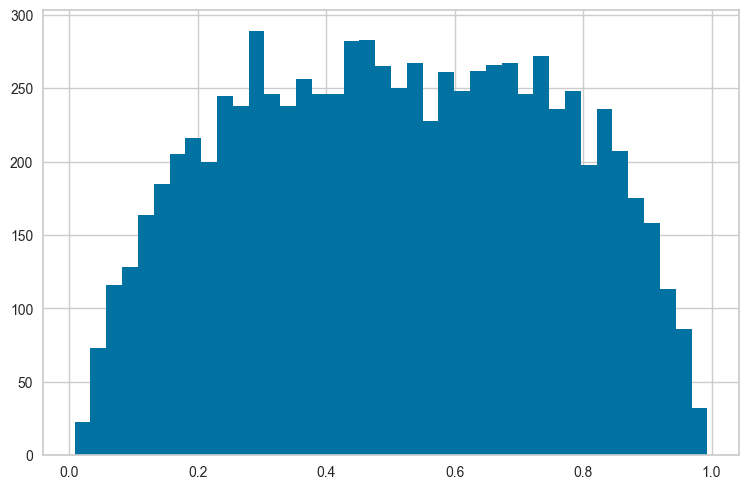

In [12]:
plt.hist(nuisance_e,bins=40)

In [13]:
print(min(nuisance_e))
print(max(nuisance_e))

0.008599996566772461
0.9934999942779541


In [14]:
np.quantile(nuisance_e,q=[0,0.05,0.1,0.2,0.8,0.9,0.95,1.0])

array([0.0086    , 0.12129998, 0.17559999, 0.26749998, 0.7482    ,
       0.838     , 0.890805  , 0.99349999])

In [15]:
nuisance_e[nuisance_e<1e-07]=1e-07
nuisance_e[nuisance_e>(1-1e-07)]=1-1e-07

(array([  1.,   2.,   0.,   3.,  10.,  41., 130., 349., 508., 567., 573.,
        527., 532., 469., 526., 591., 712., 775., 666., 475., 348., 206.,
        120.,  76.,  68.,  33.,  34.,  17.,  13.,  12.,   4.,   4.,   0.,
          2.,   4.,   0.,   0.,   0.,   1.,   1.]),
 array([-2.43264053, -2.25461542, -2.07659031, -1.89856521, -1.7205401 ,
        -1.54251499, -1.36448988, -1.18646477, -1.00843966, -0.83041455,
        -0.65238944, -0.47436434, -0.29633923, -0.11831412,  0.05971099,
         0.2377361 ,  0.41576121,  0.59378632,  0.77181143,  0.94983653,
         1.12786164,  1.30588675,  1.48391186,  1.66193697,  1.83996208,
         2.01798719,  2.1960123 ,  2.3740374 ,  2.55206251,  2.73008762,
         2.90811273,  3.08613784,  3.26416295,  3.44218806,  3.62021317,
         3.79823827,  3.97626338,  4.15428849,  4.3323136 ,  4.51033871,
         4.68836382]),
 <BarContainer object of 40 artists>)

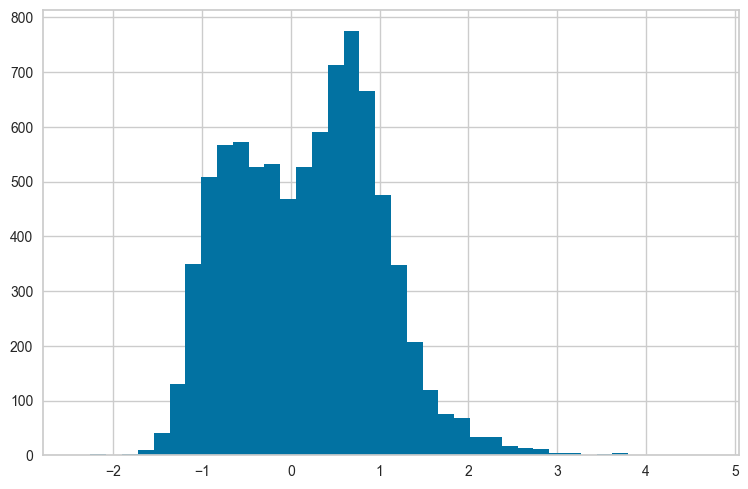

In [16]:
plt.hist(nuisance_m1-nuisance_m0,bins=40)

metrics function

In [17]:
from sklearn.neighbors import KNeighborsRegressor

def DR_risk_score(cate_pred, y, t, y1_pred, y0_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    dr_pseudo = (t / t_pred - (1 - t) / (1 - t_pred)) * y \
                + (1 - t / t_pred) * y1_pred \
                - (1 - (1 - t) / (1 - t_pred)) * y0_pred
    score = np.mean((dr_pseudo - cate_pred)**2)
    return score

def R_risk_score(cate_pred, y, t, mu_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    y_tilde = y - mu_pred
    t_tilde = t - t_pred
    r_pseudo = y_tilde / t_tilde
    r_weight = t_tilde**2
    score = np.mean(r_weight*((r_pseudo - cate_pred)**2))
    return score

def T_risk_score(cate_pred, y, t, y1_pred, y0_pred):
    pseudo_outcome = np.zeros_like(y)
    pseudo_outcome[t == 0] = y1_pred[t == 0] - y[t == 0]
    pseudo_outcome[t == 1] = y[t == 1] - y0_pred[t == 1]
    score = np.mean((pseudo_outcome - cate_pred)**2)
    return score

def U_risk_score(cate_pred, y, t, mu_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    y_tilde = y - mu_pred
    t_tilde = t - t_pred
    U_pseudo = y_tilde / t_tilde
    score = np.mean((U_pseudo - cate_pred)**2)
    return score

def F_risk_score(cate_pred, y, t, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    f_pseudo = y * (t - t_pred) / (t_pred * (1 - t_pred))
    score = np.mean((f_pseudo - cate_pred)**2)
    return score

def KNN_score(cate_pred, y, t, X, k=1):
    nn0 = KNeighborsRegressor(n_neighbors=k, weights="distance")
    nn1 = KNeighborsRegressor(n_neighbors=k, weights="distance")
    nn0 = nn0.fit(X[t == 0], y[t == 0])
    nn1 = nn1.fit(X[t == 1], y[t == 1])

    y_cf = np.zeros_like(y)
    y_cf[t == 0] = nn1.predict(X[t == 0])
    y_cf[t == 1] = nn0.predict(X[t == 1])
    ite_nn = np.zeros_like(y)
    ite_nn[t == 0] = y_cf[t == 0] - y[t == 0]
    ite_nn[t == 1] = y[t == 1] - y_cf[t == 1]
    score = np.mean((ite_nn - cate_pred)**2)
    return score

def IF_score(cate_pred, y, t, y1_pred, y0_pred, t_pred, CLIP=1e-10):
    t_pred = np.clip(t_pred, CLIP, 1 - CLIP)
    y_factual = y
    pseudo_outcomes = y1_pred - y0_pred
    d_term = t - t_pred
    c_term = t_pred * (1 - t_pred)
    b_term = 2 * t * (t - t_pred) / c_term
    objective_value = ((1 - b_term) * (pseudo_outcomes ** 2) +
                           b_term * y_factual * (pseudo_outcomes - cate_pred) -
                           d_term * (pseudo_outcomes - cate_pred) ** 2 + cate_pred ** 2)
    score = np.mean(objective_value)
    return score

In [18]:
import optuna
import optuna.trial as trial
import gc

def objective(trial, x_train=XX, t_train=treatmentX, y_train=yX, ym=np.array(ym), ys=np.array(ys),
              nuisance_e=nuisance_e, nuisance_m=nuisance_m, nuisance_m1=nuisance_m1, nuisance_m0=nuisance_m0):

    try:
        # split data to training & validation
        np.random.seed(61985)
        val_split = 0.3
        size = int(x_train.shape[0]*(1-val_split))
        ind = np.random.permutation(np.array(list(range(x_train.shape[0]))))
        ind_tr = ind[:size]
        ind_te = ind[size:]
        x_train_tr = x_train.iloc[ind_tr,:]
        t_train_tr = t_train.iloc[ind_tr]
        y_train_tr = y_train.iloc[ind_tr]
        x_train_te = x_train.iloc[ind_te,:]
        t_train_te = t_train.iloc[ind_te]
        y_train_te = y_train.iloc[ind_te]
        true_ite_train_te = true_ite_train[ind_te]

        e_tr = nuisance_e[ind_tr]
        e_te = nuisance_e[ind_te]
        m_te = nuisance_m[ind_te]
        m_te = m_te*ys+ym
        m1_te = nuisance_m1[ind_te]
        m1_te = m1_te*ys+ym
        m0_te = nuisance_m0[ind_te]
        m0_te = m0_te*ys+ym

        params = {
            'neurons_r_layer_w': trial.suggest_int('neurons_r_layer_w', 1, x_train.shape[1]*0.5, 1),
            "neurons_r_layer_c0": trial.suggest_int("neurons_r_layer_c0", 1, x_train.shape[1]*0.5, 1),
            'neurons_r_layer_o0': trial.suggest_int('neurons_r_layer_o0', 1, x_train.shape[1]*0.5, 1),
            'neurons_r_layer_o1': trial.suggest_int('neurons_r_layer_o1', 1, x_train.shape[1]*0.5, 1),
            'neurons_out_layer': trial.suggest_float('neurons_out_layer', 1, 5),
            'num_layers': trial.suggest_int('num_layers', 1, 4, 1),
            'alpha': trial.suggest_float('alpha', -4, 2.000001),
            'ratio': trial.suggest_float('ratio', -4, 1.000001),
            'ratio2': trial.suggest_float('ratio2', -4, 1.000001),
            'ratio3': trial.suggest_float('ratio3', -4, 1.000001),
            'ratio4': trial.suggest_float('ratio4', -4, 1.000001),
            'ratio5': trial.suggest_float('ratio5', -4, 1.000001),
            'ratio6': trial.suggest_float('ratio6', -4, 1.000001),
            'beta': trial.suggest_float('beta', 0, 0),
            'reg_l2': trial.suggest_int('reg_l2', -6, -1),
            'batch_size': trial.suggest_int('batch_size', 7, 7),
            'learning_rate': trial.suggest_float('learning_rate', -6, -6),
        }
        #training
        def dragonnet_mu_risk_ce(concat_true, concat_pred, alpha=round(10**params["alpha"],7)):
            return mu_risk_ce_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)

        def seed_every(seed):
            random.seed(seed)
            np.random.seed(seed)
            tf.random.set_seed(seed)
        seed_every(805619) 
        gsnet =  GSNet_R(loss_func=dragonnet_mu_risk_ce,\
                neurons_r_layer_w = params["neurons_r_layer_w"], \
                neurons_r_layer_c0 = params["neurons_r_layer_c0"],\
                neurons_r_layer_o0 = params["neurons_r_layer_o0"], neurons_r_layer_o1 = params["neurons_r_layer_o1"], \
                neurons_out_layer = int(2**params["neurons_out_layer"]), num_layers = params["num_layers"],\
                batch_size = 2**params["batch_size"], learning_rate = 10**params["learning_rate"], epochs = 500, \
                reg_disc = True, ratio = round(10**params["ratio"],4), ratio2 = round(10**params["ratio2"],4), \
                ratio3 = round(10**params["ratio3"],4), ratio4 = round(10**params["ratio4"],4), \
                ratio5 = round(10**params["ratio5"],4), ratio6 = round(10**params["ratio6"],4), \
                beta = round(params["beta"],4), reg_l2 = 10**params["reg_l2"])
        
        with contextlib.redirect_stdout(io.StringIO()):
            gsnet_ite_initial = gsnet.fit_predict(x_train_tr, t_train_tr, y_train_tr, e_tr, return_components=False)
            gsnetpred = gsnet.predict(x_train_te,t_train_te)
            gsnetpred0 = gsnet.predict(x_train_te, np.zeros(len(t_train_te)))[:,0]
            gsnetpred1 = gsnet.predict(x_train_te, np.ones(len(t_train_te)))[:,0]
            gsnetpred[:,0] = gsnetpred0*ys + ym
            gsnetpred[:,1] = gsnetpred1*ys + ym
        
        mu = np.array(gsnetpred[:,1])*np.array(t_train_te) + np.array(gsnetpred[:,0])*(1-np.array(t_train_te))
        MSE_Y = np.mean((np.array(y_train_te*ys + ym)-mu)**2)
        CE = log_loss(np.array(t_train_te),np.array(gsnetpred[:,2]))

        gsnet_ite = np.array(gsnetpred[:,1])-np.array(gsnetpred[:,0])
        yy = np.array(y_train_te*ys + ym)
        tt = np.array(t_train_te)
        xx = np.array(x_train_te)
        yy_tr = np.array(y_train_tr*ys + ym)
        tt_tr = np.array(t_train_tr)
        ATE_naive = np.mean(yy_tr[tt_tr==1]) - np.mean(yy_tr[tt_tr==0])
        ate = np.repeat(a=ATE_naive, repeats=len(yy))

        # DR-risk
        DR_risk1 = DR_risk_score(gsnet_ite,yy,tt,m1_te,m0_te,e_te)
        DR_baseline = DR_risk_score(ate,yy,tt,m1_te,m0_te,e_te)
        DR_risk = DR_risk1/DR_baseline
        # R-risk
        R_risk1 = R_risk_score(gsnet_ite,yy,tt,m_te,e_te)
        R_baseline = R_risk_score(ate,yy,tt,m_te,e_te)
        R_risk = R_risk1/R_baseline
        # T-risk
        T_risk1 = T_risk_score(gsnet_ite,yy,tt,m1_te,m0_te)
        T_baseline = T_risk_score(ate,yy,tt,m1_te,m0_te)
        T_risk = T_risk1/T_baseline
        # U-risk
        U_risk1 = U_risk_score(gsnet_ite,yy,tt,m_te,e_te)
        U_baseline = U_risk_score(ate,yy,tt,m_te,e_te)
        U_risk = U_risk1/U_baseline
        # F-risk
        F_risk1 = F_risk_score(gsnet_ite,yy,tt,e_te)
        F_baseline = F_risk_score(ate,yy,tt,e_te)
        F_risk = F_risk1/F_baseline
        # KNN
        KNN_val1 = KNN_score(gsnet_ite,yy,tt,xx)
        KNN_baseline = KNN_score(ate,yy,tt,xx)
        KNN_val = KNN_val1/KNN_baseline
        # IF
        IF_val1 = IF_score(gsnet_ite,yy,tt,m1_te,m0_te,e_te)
        IF_baseline = IF_score(ate,yy,tt,m1_te,m0_te,e_te)
        IF_val = IF_val1/IF_baseline
        # CE
        y_hat_naive = np.repeat(a=np.mean(yy_tr), repeats=len(yy))
        MSE_Ybaseline = np.mean((yy-y_hat_naive)**2)
        MSE_Y = MSE_Y/MSE_Ybaseline
        t_hat_naive = np.repeat(a=np.mean(tt_tr), repeats=len(tt))
        CE_Tbaseline = log_loss(tt, t_hat_naive)
        CE_T = CE/CE_Tbaseline

        # mu-risk-ce
        ww=1+np.log(0.5)
        a = (np.array(y_train_te*ys + ym) -mu)**2
        pp = e_te
        pp[pp<1e-7]=1e-7
        pp[pp>(1-1e-7)]=(1-1e-7)
        b = -(np.array(t_train_te)*np.log(pp)+(1-np.array(t_train_te))*np.log(1-pp))+ww
        mu_risk_ce = np.mean(a*b)

        # pehe
        pehe_valid = np.sqrt(np.mean((true_ite_train_te.numpy().squeeze()-gsnet_ite)**2))


        print(f"pehe={pehe_valid}, DR_risk={DR_risk}, R_risk={R_risk}, mu_risk_ce={mu_risk_ce}, CE_T={CE}, CE_e={np.mean(b)-ww}")
        trial.set_user_attr("DR_risk", DR_risk)
        trial.set_user_attr("R_risk", R_risk)
        trial.set_user_attr("T_risk", T_risk)
        trial.set_user_attr("U_risk", U_risk)
        trial.set_user_attr("F_risk", F_risk)
        trial.set_user_attr("KNN_val", KNN_val)
        trial.set_user_attr("IF", IF_val)
        trial.set_user_attr("CE", CE_T)
        trial.set_user_attr("MSE", MSE_Y)
        trial.set_user_attr("IF", IF_val)
        
        return mu_risk_ce + CE
    
    finally:
        if 'gsnet' in locals():
            del gsnet
        if 'gsnetpred' in locals():
            del gsnetpred
        tf.keras.backend.clear_session()
        gc.collect()

In [ ]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sampler = optuna.samplers.TPESampler(seed=85619)
    study = optuna.create_study(direction="minimize",sampler=sampler)
    study.optimize(objective, n_trials = 130)

[I 2026-08-29 12:22:49,446] A new study created in memory with name: no-name-767540c5-5c11-4e03-9a2d-308411b65edc


[W 2026-08-29 12:22:50,772] Trial 0 failed with parameters: {'neurons_r_layer_w': 12, 'neurons_r_layer_c0': 3, 'neurons_r_layer_o0': 2, 'neurons_r_layer_o1': 10, 'neurons_out_layer': 3.166188317680785, 'num_layers': 2, 'alpha': -2.0290011277091002, 'ratio': 0.923152620792048, 'reg_l2': -5, 'batch_size': 7, 'learning_rate': -5.60578273552371} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\ASUS\anaconda3\envs\causalml-env\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Local\Temp\ipykernel_43336\904646251.py", line 71, in objective
    gsnet_ite_initial = gsnet.fit_predict(x_train_tr, t_train_tr, y_train_tr, e_tr, return_components=False)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Local\Temp\ipykernel_43336\432682895.p

KeyboardInterrupt: 

In [19]:
plotly_config = {"staticPlot": True}
fig = plot_optimization_history(study)
fig.show(config=plotly_config)

NameError: name 'study' is not defined

In [ ]:
study.best_trial.params

{'neurons_r_layer_w': 10,
 'neurons_r_layer_c0': 9,
 'neurons_r_layer_o0': 4,
 'neurons_r_layer_o1': 9,
 'neurons_out_layer': 3.269096239050042,
 'num_layers': 2,
 'alpha': -2.68744268391922,
 'ratio': -1.8028639883920288,
 'batch_size': 8,
 'learning_rate': -5.197196176435936,
 'reg_l2': -6}

------------------------------------------------------------------------------

In [ ]:
args = {
    'model_name':"SNet_yc",
    'neurons_r_layer_w': study.best_trial.params['neurons_r_layer_w'],
    'neurons_r_layer_c0': study.best_trial.params['neurons_r_layer_c0'],
    'neurons_r_layer_o0': study.best_trial.params['neurons_r_layer_o0'],
    'neurons_r_layer_o1': study.best_trial.params['neurons_r_layer_o1'],
    'neurons_out_layer': int(2**study.best_trial.params['neurons_out_layer']),
    'num_layers': study.best_trial.params['num_layers'],
    'alpha':round(10**study.best_trial.params['alpha'],7),
    'ratio':round(10**study.best_trial.params['ratio'],4),
    'ratio2':round(10**study.best_trial.params['ratio2'],4),
    'ratio3':round(10**study.best_trial.params['ratio3'],4),
    'ratio4':round(10**study.best_trial.params['ratio4'],4),
    'ratio5':round(10**study.best_trial.params['ratio5'],4),
    'ratio6':round(10**study.best_trial.params['ratio6'],4),
    'beta':round(study.best_trial.params['beta'],4),
    'batch_size':2**study.best_trial.params["batch_size"],
    'learning_rate':10**study.best_trial.params["learning_rate"],
    'reg_l2':10**study.best_trial.params["reg_l2"]
}
args

{'model_name': 'SNet_yc',
 'neurons_r_layer_w': 10,
 'neurons_r_layer_c0': 9,
 'neurons_r_layer_o0': 4,
 'neurons_r_layer_o1': 9,
 'neurons_out_layer': 9,
 'num_layers': 2,
 'alpha': 0.0020538,
 'ratio': 0.0157448,
 'ratio2': 0.0,
 'batch_size': 256,
 'learning_rate': 6.3504400945871795e-06,
 'reg_l2': 1e-06}

In [40]:
args = {
    'model_name': 'SNet_yc',
    'neurons_r_layer_w': 9,
    'neurons_r_layer_c0': 2,
    'neurons_r_layer_o0': 2,
    'neurons_r_layer_o1': 8,
    'neurons_out_layer': 13,
    'num_layers': 2,
    'alpha': 0.009354,
    'ratio': 0.1,
    'ratio2': 0.0,
    'ratio3': 0.1,
    'ratio4': 0.0,
    'ratio5': 1,
    'ratio6': 1,
    'batch_size': 128,
    'learning_rate': 1e-06,
    'reg_l2': 0.01
}
args

{'model_name': 'SNet_yc',
 'neurons_r_layer_w': 9,
 'neurons_r_layer_c0': 2,
 'neurons_r_layer_o0': 2,
 'neurons_r_layer_o1': 8,
 'neurons_out_layer': 13,
 'num_layers': 2,
 'alpha': 0.009354,
 'ratio': 0.1,
 'ratio2': 0.0,
 'ratio3': 0.1,
 'ratio4': 0.0,
 'ratio5': 1,
 'ratio6': 1,
 'batch_size': 128,
 'learning_rate': 1e-06,
 'reg_l2': 0.01}

In [19]:
args = {
    'model_name': 'SNet_yc',
    'neurons_r_layer_w': 11,
    'neurons_r_layer_c0': 8,
    'neurons_r_layer_o0': 11,
    'neurons_r_layer_o1': 12,
    'neurons_out_layer': 12,
    'num_layers': 1,
    'alpha': 0.0463,
    'ratio': 0.0033,
    'ratio2': 0.0,
    'ratio3': 0.0167,
    'ratio4': 0.0,
    'ratio5': 0.0040,
    'ratio6': 2.8554,
    'batch_size': 128,
    'learning_rate': 1e-06,
    'reg_l2': 0.01
}
args

{'model_name': 'SNet_yc',
 'neurons_r_layer_w': 11,
 'neurons_r_layer_c0': 8,
 'neurons_r_layer_o0': 11,
 'neurons_r_layer_o1': 12,
 'neurons_out_layer': 12,
 'num_layers': 1,
 'alpha': 0.0463,
 'ratio': 0.0033,
 'ratio2': 0.0,
 'ratio3': 0.0167,
 'ratio4': 0.0,
 'ratio5': 0.004,
 'ratio6': 2.8554,
 'batch_size': 128,
 'learning_rate': 1e-06,
 'reg_l2': 0.01}

In [62]:
yss = ys
ymm = ym
ys = np.array(yss)
ym = np.array(ymm)
def dragonnet_mu_risk_ce(concat_true, concat_pred, alpha=args['alpha']):
    return mu_risk_ce_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)
def dragonnet_loss_binarycross(concat_true, concat_pred, alpha=args['alpha']):
    return regression_loss(concat_true, concat_pred) + alpha*binary_classification_loss(concat_true, concat_pred)

def seed_every(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
# seed_every(805619)
# seed_every(619805)
seed_every(805)
# seed_every(85619)
gsnet =  GSNet_R(loss_func=dragonnet_mu_risk_ce,\
                   neurons_r_layer_w = args["neurons_r_layer_w"], \
                   neurons_r_layer_c0 = args["neurons_r_layer_c0"],\
                   neurons_r_layer_o0 = args["neurons_r_layer_o0"], neurons_r_layer_o1 = args["neurons_r_layer_o1"], \
                   neurons_out_layer = args["neurons_out_layer"], num_layers = args["num_layers"],\
                   batch_size = args["batch_size"], learning_rate = args["learning_rate"], epochs = 500, \
                   reg_disc = True, ratio = args["ratio"], ratio2 = args["ratio2"], ratio3 = args["ratio3"], \
                   ratio4 = args["ratio4"], ratio5 = args["ratio5"], ratio6 = args["ratio6"], \
                   reg_l2 = args["reg_l2"])

gsnet_ite_initial = gsnet.fit_predict(XX, treatmentX, yX, nuisance_e, return_components=False)
gsnet_ite_initial=gsnet_ite_initial*ys
gsnet_ate_initial = gsnet_ite_initial.mean()
gsnetpred=gsnet.predict(X, treatment, y)
gsnetpred0=gsnet.predict(X, np.zeros(len(treatment)))[:,0]
gsnetpred1=gsnet.predict(X, np.ones(len(treatment)))[:,0]
gsnetpred[:,0]=gsnetpred0*ys+ym
gsnetpred[:,1]=gsnetpred1*ys+ym

df_preds_initial = pd.DataFrame([gsnetpred[:,1]-gsnetpred[:,0],
                                 treatment.ravel(),
                                 y.ravel()],
                                 index=['gsnet','w','y']).T

Temperature = 0.0001
Epoch 1/800
46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - binary_classification_loss: 88.6633 - loss: 111.4151 - mu_risk_ce_loss: 106.8295 - track_epsilon: 0.0088 - treatment_accuracy: 0.5094 - val_binary_classification_loss: 86.8962 - val_loss: 101.5743 - val_mu_risk_ce_loss: 96.9359 - val_track_epsilon: 0.0088 - val_treatment_accuracy: 0.5786 - learning_rate: 0.0010
Temperature = 0.0014
Epoch 2/800
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - binary_classification_loss: 87.9089 - loss: 94.6242 - mu_risk_ce_loss: 89.8499 - track_epsilon: 0.0088 - treatment_accuracy: 0.5705 - val_binary_classification_loss: 84.4795 - val_loss: 88.4295 - val_mu_risk_ce_loss: 83.9958 - val_track_epsilon: 0.0088 - val_treatment_accuracy: 0.5802 - learning_rate: 0.0010
Temperature = 0.0026
Epoch 3/800
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_classification_loss: 86.5883 - loss: 86.7686 - mu_risk_ce_loss: 82.2696 - track_epsilon: 0.0088 - treatment_accuracy: 0.5660 - val_binary_classi

In [63]:
for i, encoder in enumerate(gsnet.model.embedded.encoders):
        gaussian = encoder.layers[0]
        print(f"Feature {i}:")
        print(gaussian.b_w.numpy())

Feature 0:
[ 2.1515665   0.641187    0.19874597 -3.018741   -0.13199604 -0.03353483
 -2.5837116  -1.4678768   0.6517423  -0.48212937 -0.03293741 -0.26532626]
Feature 1:
[ 1.6226135 -2.1790323 -1.1731044 -0.7788934  0.5139514  1.2831504
  3.0619411 -1.8886582 -2.8826692  0.9879139 -1.0951879 -1.2466807]
Feature 2:
[-0.6545433  -3.3464487   1.6499391  -0.63843495  1.3503923   0.17056362
  2.5567422   0.9315653   0.6087532  -0.0372279   0.04540582 -1.588705  ]
Feature 3:
[ 0.3865729   3.1504266  -0.83079034  1.3697597   0.10844006 -0.3921596
 -2.113437    2.2753358   0.18508638 -1.932426   -1.0301099  -2.137569  ]
Feature 4:
[ 0.92640525  0.46212217  0.33124965 -2.185747    0.24988475  0.84408504
  2.1413565  -0.27644014  3.2390065   2.6881278   0.79870737 -0.5018372 ]
Feature 5:
[-0.48278475  0.0451023  -2.3547955   2.3780618   1.3788282   0.33941028
 -1.5974486  -2.6756353  -0.19671315  2.6055496  -0.466057    0.98264647]
Feature 6:
[-2.5133572   3.3692133  -1.7956992  -0.42253318  0.88

In [64]:
for i, encoder in enumerate(gsnet.model.embedded.encoders):
        gaussian = encoder.layers[0]
        print(f"Feature {i}:")
        print(tf.exp(gaussian.a_w).numpy())

Feature 0:
[ 7.555872   52.440845    0.38059923  0.12435505  0.52898943  1.4414253
  0.35768533  0.773031    0.07130847  0.568644    1.3902483   0.46176264]
Feature 1:
[0.9312526  2.334883   0.59282494 0.20746131 1.4100809  1.2603935
 1.0122755  1.2094132  0.8877156  6.052716   0.9437173  1.0461891 ]
Feature 2:
[ 1.995934    3.7273767  13.240162    1.163731    1.2510422   1.7846231
  1.1824709   1.1609454   0.76156753  1.7754862   1.1929802   2.073457  ]
Feature 3:
[ 3.0887387  4.724619   5.3469505  1.2522836  1.9335233  2.8095741
  2.7879095  1.1669332  1.8617963 13.081146   1.9040781  2.1764429]
Feature 4:
[ 5.5665803  1.5150529  2.0623531  1.4257159  1.3673282  1.5822886
  3.776836   1.5878073  1.4338671 59.499165   1.4792675  2.8488317]
Feature 5:
[ 2.219988    1.4706095  11.400054    2.5189703   1.9444376   1.2854047
  0.90374875  0.89509016  1.0866016   6.303548    1.1533893   1.720465  ]
Feature 6:
[ 1.2548488  2.3688886 13.587774   2.1010642  1.0815591  1.3649749
  2.252279   1

In [65]:
# layers=gsnet.dragonnet.layers
# layers_names=[]
# for i in range(len(layers)):
#     a_layer=gsnet.dragonnet.layers[i]
#     layers_names=layers_names+[a_layer.name]
# layers_names=np.array(layers_names)
# layers_names_idx=list(range(len(layers)))
# layers_names_idx=np.array(layers_names_idx)
# layers_names

# layer_w0=gsnet.dragonnet.layers[layers_names_idx[layers_names=="input_instrument"][0]]
# weights_w0,bias_w0 = layer_w0.weights
# layer_c00=gsnet.dragonnet.layers[layers_names_idx[layers_names=="input_confounder0"][0]]
# weights_c00,bias_c00 = layer_c00.weights
# layer_o00=gsnet.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment0"][0]]
# weights_o00,bias_o00 = layer_o00.weights
# layer_o01=gsnet.dragonnet.layers[layers_names_idx[layers_names=="input_adjustment1"][0]]
# weights_o01,bias_o01 = layer_o01.weights

# instrument_wts=tf.reduce_sum(tf.abs(weights_w0),axis=1)
# instrument_wts=instrument_wts/tf.sqrt(tf.reduce_sum(instrument_wts**2))
# confounder_wts0=tf.reduce_sum(tf.abs(weights_c00),axis=1)
# confounder_wts0=confounder_wts0/tf.sqrt(tf.reduce_sum(confounder_wts0**2))
# adjustment_wts0=tf.reduce_sum(tf.abs(weights_o00),axis=1)
# adjustment_wts0=adjustment_wts0/tf.sqrt(tf.reduce_sum(adjustment_wts0**2))
# adjustment_wts1=tf.reduce_sum(tf.abs(weights_o01),axis=1)
# adjustment_wts1=adjustment_wts1/tf.sqrt(tf.reduce_sum(adjustment_wts1**2))

# print("instrument block vs covariates")
# print(instrument_wts)
# print()
# print("confounder0 block vs covariates")
# print(confounder_wts0)
# print()
# print("adjustment0 block vs covariates")
# print(adjustment_wts0)
# print()
# print("adjustment1 block vs covariates")
# print(adjustment_wts1)
# print()
# aa = tf.reduce_sum(instrument_wts*confounder_wts0)
# cc = tf.reduce_sum(instrument_wts*adjustment_wts0)
# dd = tf.reduce_sum(instrument_wts*adjustment_wts1)
# ff = tf.reduce_sum(confounder_wts0*adjustment_wts0)
# gg = tf.reduce_sum(confounder_wts0*adjustment_wts1)
# jj = tf.reduce_sum(adjustment_wts0*adjustment_wts1)
# print(f"zt vs zc0: {aa}")
# print(f"zt vs zy0: {cc}")
# print(f"zt vs zy1: {dd}")
# print(f"zc0 vs zy0: {ff}")
# print(f"zc0 vs zy1: {gg}")
# print(f"zy0 vs zy1: {jj}")
# print(f"total: {aa+cc+dd+ff+gg+jj}")

# import seaborn as sns
# all_latent_wts={"instrument_wts":np.array(instrument_wts),
#                 "confounder_wts0":np.array(confounder_wts0),
#                 "adjustment_wts0":np.array(adjustment_wts0),
#                 "adjustment_wts1":np.array(adjustment_wts1)}
# all_latent_wts=pd.DataFrame(all_latent_wts).T
# plt.rcParams['figure.figsize'] = 10.0, 6.0
# sns.heatmap(all_latent_wts,annot_kws={"size":10},cmap="Reds")
# plt.xticks(fontsize=10)
# plt.yticks(fontsize=10)
# plt.show()

(array([562., 408., 349., 299., 282., 248., 242., 258., 278., 270., 247.,
        247., 243., 255., 284., 271., 275., 273., 294., 303., 304., 286.,
        302., 293., 301., 296., 262., 267., 277., 289., 266., 268., 278.,
        278., 285., 279., 316., 350., 435., 480.]),
 array([5.29865720e-05, 2.50460804e-02, 5.00391722e-02, 7.50322640e-02,
        1.00025363e-01, 1.25018448e-01, 1.50011539e-01, 1.75004646e-01,
        1.99997738e-01, 2.24990830e-01, 2.49983922e-01, 2.74977028e-01,
        2.99970120e-01, 3.24963212e-01, 3.49956304e-01, 3.74949396e-01,
        3.99942487e-01, 4.24935579e-01, 4.49928671e-01, 4.74921763e-01,
        4.99914855e-01, 5.24907947e-01, 5.49901068e-01, 5.74894130e-01,
        5.99887252e-01, 6.24880314e-01, 6.49873435e-01, 6.74866498e-01,
        6.99859619e-01, 7.24852681e-01, 7.49845803e-01, 7.74838865e-01,
        7.99831986e-01, 8.24825048e-01, 8.49818170e-01, 8.74811232e-01,
        8.99804354e-01, 9.24797416e-01, 9.49790537e-01, 9.74783599e-01,
      

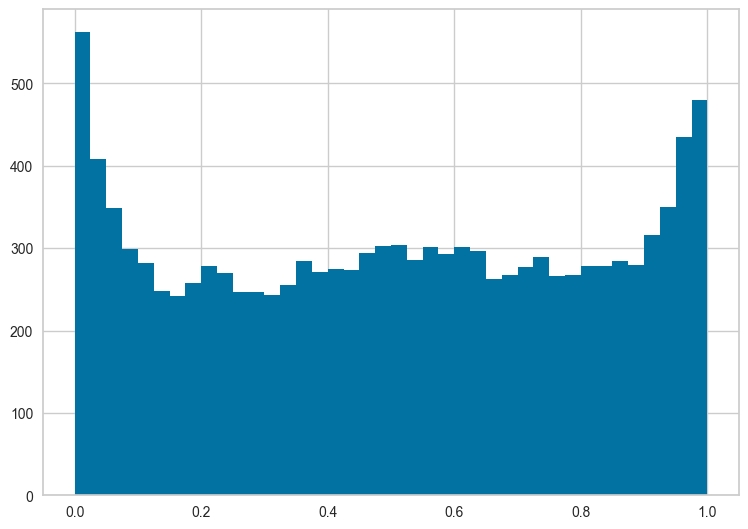

In [66]:
plt.rcParams['figure.figsize'] = 8.0, 6.0
plt.hist(gsnetpred[:,2],bins=40)

          gsnet    w         y
0     -1.004245  0.0  0.421445
1      0.660133  0.0 -0.024604
2     -0.665308  0.0  1.485467
3     -0.858919  1.0 -0.458699
4      1.026356  1.0  1.114336
...         ...  ...       ...
11995  0.423999  0.0 -1.350952
11996  0.936126  0.0 -0.046919
11997  0.875878  0.0  0.566376
11998  1.285424  0.0  0.685549
11999  0.712055  1.0  1.299354

[12000 rows x 3 columns]


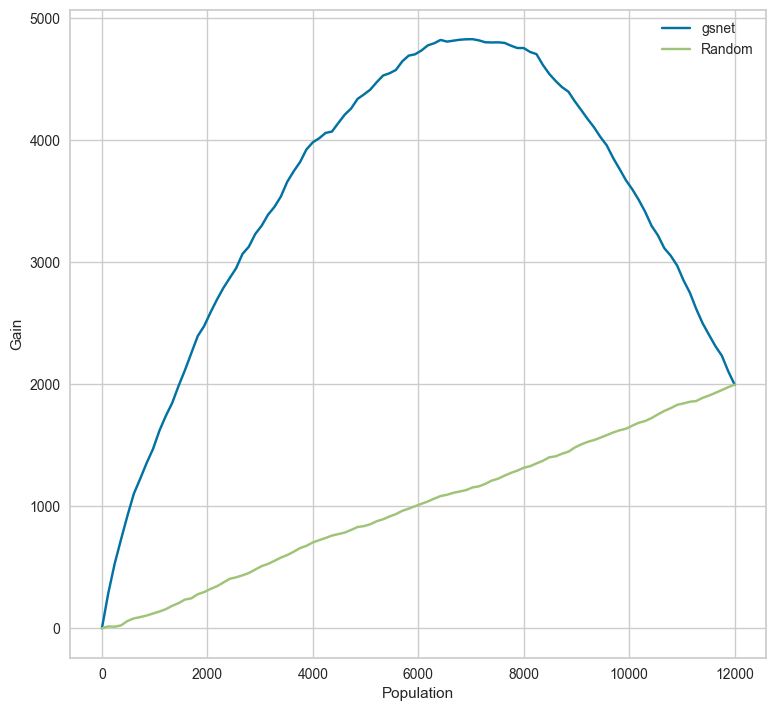

In [67]:
print(df_preds_initial)
plt.rcParams['figure.figsize'] = 10.0, 7.5
plot_gain(df_preds_initial)
plt.show()

--------------------------------------------------------------------------------------------------------------------------------------------------------

ITE estimate

In [68]:
gsnet_pred=gsnet.predict(Xt,treatmentt)
gsnet_pred0=gsnet.predict(Xt, np.zeros(len(treatmentt)))[:,0]
gsnet_pred1=gsnet.predict(Xt, np.ones(len(treatmentt)))[:,0]
gsnet_pred[:,0]=gsnet_pred0*ys+ym
gsnet_pred[:,1]=gsnet_pred1*ys+ym
gsnet_pred_tr=gsnet.predict(XX,treatmentX)
gsnet_pred0_tr=gsnet.predict(XX, np.zeros(len(treatmentX)))[:,0]
gsnet_pred1_tr=gsnet.predict(XX, np.ones(len(treatmentX)))[:,0]
gsnet_pred_tr[:,0]=gsnet_pred0_tr*ys+ym
gsnet_pred_tr[:,1]=gsnet_pred1_tr*ys+ym
gsnet_pred_all=gsnet.predict(X,treatment)
gsnet_pred0_all=gsnet.predict(X, np.zeros(len(treatment)))[:,0]
gsnet_pred1_all=gsnet.predict(X, np.ones(len(treatment)))[:,0]
gsnet_pred_all[:,0]=gsnet_pred0_all*ys+ym
gsnet_pred_all[:,1]=gsnet_pred1_all*ys+ym

gsnet_ite = np.array(gsnet_pred[:,1]-gsnet_pred[:,0])
gsnet_ite_tr = np.array(gsnet_pred_tr[:,1]-gsnet_pred_tr[:,0])
gsnet_ite_all = np.array(gsnet_pred_all[:,1]-gsnet_pred_all[:,0])

gsnet_t = np.array(gsnet_pred[:,2])
gsnet_t_tr = np.array(gsnet_pred_tr[:,2])
gsnet_t_all = np.array(gsnet_pred_all[:,2])

gsnet_y1 = np.array(gsnet_pred[:,1])
gsnet_y1_tr = np.array(gsnet_pred_tr[:,1])
gsnet_y1_all = np.array(gsnet_pred_all[:,1])

gsnet_y0 = np.array(gsnet_pred[:,0])
gsnet_y0_tr = np.array(gsnet_pred_tr[:,0])
gsnet_y0_all = np.array(gsnet_pred_all[:,0])

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [28]:
#1
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.05804 0.08963 0.07926 0.10596 0.04251 0.0913  0.11039 0.09351 0.11384
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.10491 0.07964 0.15342 0.      0.06097 0.10116 0.
 0.05432 0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.08893 0.04626 0.07    0.1208
 0.10075 0.0726  0.12271 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.18469
 0.      0.      0.      0.17906 0.14271 0.18165 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [40]:
#1
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.10537 0.06968 0.08045 0.10485 0.      0.10517 0.05985 0.09813 0.10525
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.08483 0.07913 0.08995 0.07681 0.085   0.07711 0.
 0.08562 0.067   0.08392 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.09288 0.06191 0.09027 0.06937 0.0905  0.09179 0.09356
 0.09036 0.07036 0.08108 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.16489
 0.      0.      0.      0.17901 0.16653 0.18251 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [49]:
#2
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.08577 0.09632 0.09825 0.09936 0.05516 0.09429 0.10408 0.08811 0.09676
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.07797 0.05682 0.06538 0.10934 0.06936 0.11408 0.05628
 0.0713  0.06361 0.07162 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.05718 0.09065 0.10437 0.07994 0.07596 0.04262 0.
 0.06097 0.04426 0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.17699
 0.      0.      0.      0.17386 0.17314 0.17271 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [45]:
#2
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.11903 0.09283 0.05771 0.      0.      0.135   0.07599 0.07477 0.13589
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.10114 0.08515 0.09876 0.0613  0.09229 0.08653 0.
 0.05899 0.08337 0.08433 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.09578 0.05521 0.09729 0.06384 0.09481 0.09029 0.09708
 0.09408 0.07047 0.07746 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.17892
 0.      0.      0.      0.16468 0.17298 0.17895 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [69]:
#3
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.10654 0.1052  0.1041  0.07913 0.09004 0.09596 0.08709 0.09285 0.08081
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.05521 0.07849 0.08919 0.08922 0.05243 0.09372 0.0823
 0.08217 0.05111 0.04696 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.0587  0.07857 0.0948  0.05262 0.07843 0.10333 0.09605
 0.08058 0.08238 0.08927 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.18296
 0.      0.      0.      0.18412 0.14294 0.18015 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [32]:
#3
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.28779 0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.12439 0.06141 0.12872 0.1287  0.12949 0.12013
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.05846 0.      0.0598  0.      0.07145 0.07117 0.04963 0.08205 0.14892
 0.0594  0.15952 0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.1853
 0.      0.      0.      0.13425 0.14014 0.22032 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [37]:
#4
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.10132 0.27671 0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.04628 0.09027 0.1563  0.      0.      0.06021 0.04716 0.10396
 0.14751 0.      0.04516 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.06852 0.      0.07675 0.09215 0.07686 0.      0.07153 0.09232
 0.09305 0.09322 0.09359 0.      0.      0.06593 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.13061
 0.      0.      0.      0.20633 0.12832 0.22437 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [ ]:
#4
aa = args["neurons_r_layer_w"]+args["neurons_r_layer_c0"]+args["neurons_r_layer_o0"]+args["neurons_r_layer_o1"]
bb = args["neurons_out_layer"]*4
ff = XX.shape[1]
a1 = np.median(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)],axis=0)
a1[a1<=0.04]=0
print(np.round(a1,5))
print("")
a2 = np.median(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)],axis=0)
a2[a2<=0.04]=0
print(np.round(a2,5))
print("")
a3 = np.median(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)],axis=0)
a3[a3<=0.04]=0
print(np.round(a3,5))
print("")
a4 = np.median(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)],axis=0)
a4[a4<=0.04]=0
print(np.round(a4,5))

[0.      0.      0.      0.      0.      0.      0.      0.12603 0.04447
 0.      0.      0.      0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.06969 0.10534 0.10529 0.      0.10527 0.      0.10522
 0.09916 0.10344 0.10393 0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.04122 0.10949 0.07044 0.      0.07417 0.04209
 0.      0.18863 0.1863  0.      0.      0.      0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]

[0.      0.      0.      0.      0.      0.      0.      0.      0.10259
 0.      0.      0.      0.22788 0.08065 0.23154 0.      0.      0.
 0.      0.      0.      0.      0.      0.      0.     ]


In [52]:
hsic_loss(torch.tensor(gsnet_pred[:,(4+args["neurons_out_layer"]*0):(4+args["neurons_out_layer"]*1)]),
          torch.tensor(gsnet_pred[:,(4+args["neurons_out_layer"]*4):(4+args["neurons_out_layer"]*4+args["neurons_r_layer_w"])]))*3600

<tf.Tensor: shape=(), dtype=float32, numpy=1.8226193189620972>

In [53]:
hsic_loss(torch.tensor(gsnet_pred[:,(4+args["neurons_out_layer"]*2):(4+args["neurons_out_layer"]*3)]),tf.reshape(t_test,[-1,1]))*3600

<tf.Tensor: shape=(), dtype=float32, numpy=0.2085028737783432>

In [46]:
for i in range(x_test.shape[1]):
    print(hsic_loss(torch.tensor(gsnet_pred[:,(4+args["neurons_out_layer"]*0):(4+args["neurons_out_layer"]*1)]),tf.reshape(x_test[:,i],[-1,1]))*3600)

tf.Tensor(3.4865463, shape=(), dtype=float32)
tf.Tensor(2.154416, shape=(), dtype=float32)
tf.Tensor(1.5683949, shape=(), dtype=float32)
tf.Tensor(2.417978, shape=(), dtype=float32)
tf.Tensor(0.62963, shape=(), dtype=float32)
tf.Tensor(2.082198, shape=(), dtype=float32)
tf.Tensor(3.2923512, shape=(), dtype=float32)
tf.Tensor(2.967317, shape=(), dtype=float32)
tf.Tensor(1.7131683, shape=(), dtype=float32)
tf.Tensor(0.42508098, shape=(), dtype=float32)
tf.Tensor(0.42271355, shape=(), dtype=float32)
tf.Tensor(0.41540185, shape=(), dtype=float32)
tf.Tensor(0.42740163, shape=(), dtype=float32)
tf.Tensor(0.43509102, shape=(), dtype=float32)
tf.Tensor(0.4319807, shape=(), dtype=float32)
tf.Tensor(0.45826006, shape=(), dtype=float32)
tf.Tensor(0.43474936, shape=(), dtype=float32)
tf.Tensor(0.45134014, shape=(), dtype=float32)
tf.Tensor(0.4186917, shape=(), dtype=float32)
tf.Tensor(0.42907608, shape=(), dtype=float32)
tf.Tensor(0.4354685, shape=(), dtype=float32)
tf.Tensor(0.43242726, shape=(),

In [51]:
for i in range(x_test.shape[1]):
    print(hsic_loss(torch.tensor(gsnet_pred[:,(4+args["neurons_out_layer"]*4):(4+args["neurons_out_layer"]*4+args["neurons_r_layer_w"])]),tf.reshape(x_test[:,i],[-1,1]))*3600)

tf.Tensor(19.314953, shape=(), dtype=float32)
tf.Tensor(12.784786, shape=(), dtype=float32)
tf.Tensor(12.112292, shape=(), dtype=float32)
tf.Tensor(9.901688, shape=(), dtype=float32)
tf.Tensor(6.7027993, shape=(), dtype=float32)
tf.Tensor(23.939472, shape=(), dtype=float32)
tf.Tensor(9.356961, shape=(), dtype=float32)
tf.Tensor(17.46345, shape=(), dtype=float32)
tf.Tensor(14.093248, shape=(), dtype=float32)
tf.Tensor(0.50375956, shape=(), dtype=float32)
tf.Tensor(0.14102332, shape=(), dtype=float32)
tf.Tensor(0.30728653, shape=(), dtype=float32)
tf.Tensor(0.23371918, shape=(), dtype=float32)
tf.Tensor(0.15351681, shape=(), dtype=float32)
tf.Tensor(0.21153492, shape=(), dtype=float32)
tf.Tensor(0.5172803, shape=(), dtype=float32)
tf.Tensor(0.16810624, shape=(), dtype=float32)
tf.Tensor(0.16875379, shape=(), dtype=float32)
tf.Tensor(0.44958884, shape=(), dtype=float32)
tf.Tensor(0.2724045, shape=(), dtype=float32)
tf.Tensor(0.18876709, shape=(), dtype=float32)
tf.Tensor(0.54571813, shape

In [50]:
gsnet.model.embedded(Xt)[:,0,0]

<tf.Tensor: shape=(3600,), dtype=float32, numpy=
array([ 0.00571514,  0.9715756 , -0.02282391, ...,  0.01572945,
        0.6933185 ,  1.3426617 ], dtype=float32)>

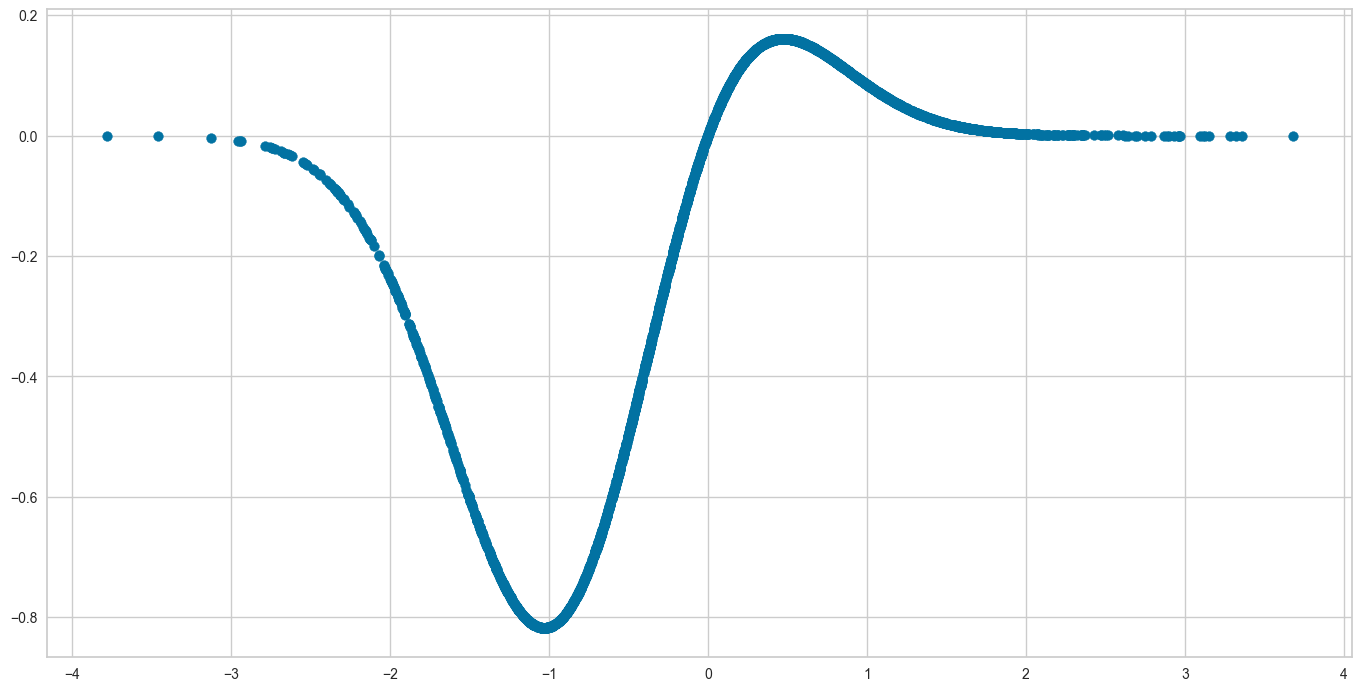

In [70]:
plt.rcParams['figure.figsize'] = 15.0, 8.0
aaa = np.array(gsnet.model.embedded(Xt)[:,11,3])[np.argsort(np.array(Xt["X12"]))]
# plt.scatter(np.sort(Xt["X12"]),gsnet_pred[:,(4+aa+bb+50+11)][np.argsort(np.array(Xt["X12"]))])
plt.scatter(np.sort(Xt["X12"]),aaa)
# plt.scatter(np.sort(Xt["X12"]),aaa*gsnet_pred[:,(4+aa+bb+50+11)][np.argsort(np.array(Xt["X12"]))])

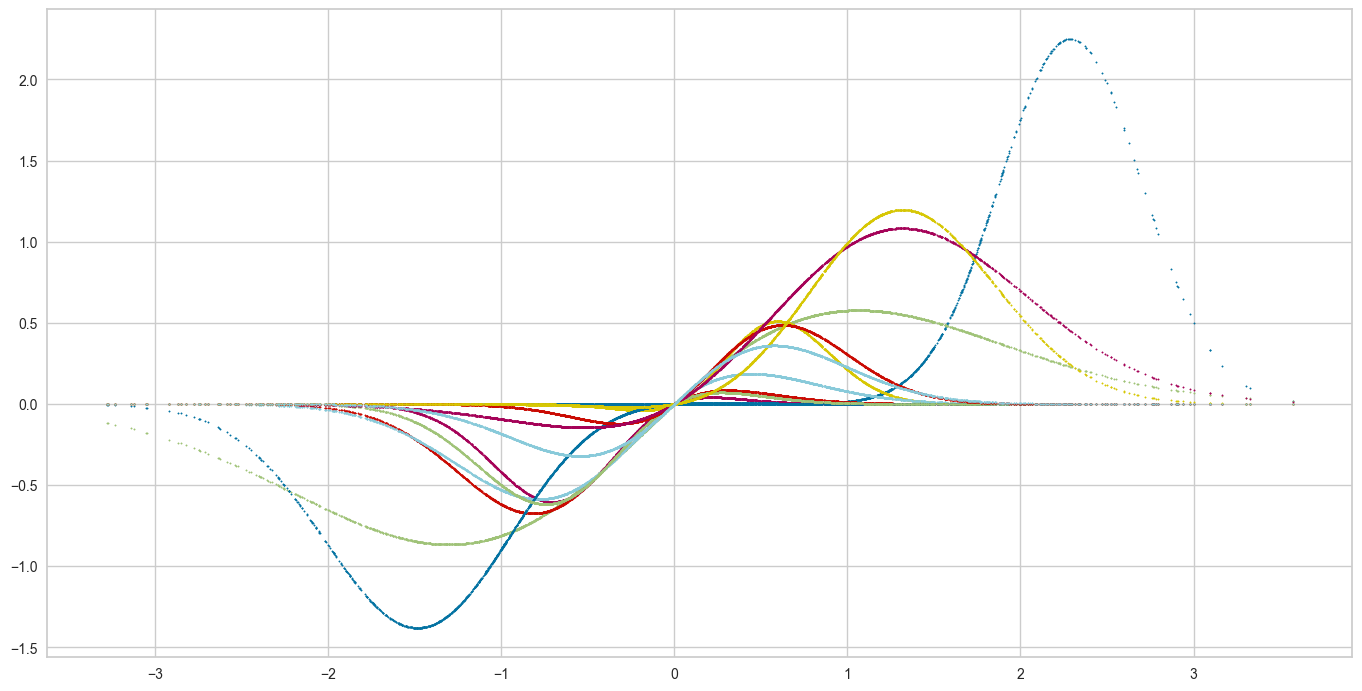

In [71]:
plt.rcParams['figure.figsize'] = 15.0, 8.0
for i in range(args["neurons_out_layer"]):
    aaa = np.array(gsnet.model.embedded(Xt)[:,19,i])[np.argsort(np.array(Xt["X20"]))]
    # plt.scatter(np.sort(Xt["X12"]),aaa*gsnet_pred[:,(4+aa+bb+50+11)][np.argsort(np.array(Xt["X12"]))],s=1)
    plt.scatter(np.sort(Xt["X20"]),aaa,s=1)

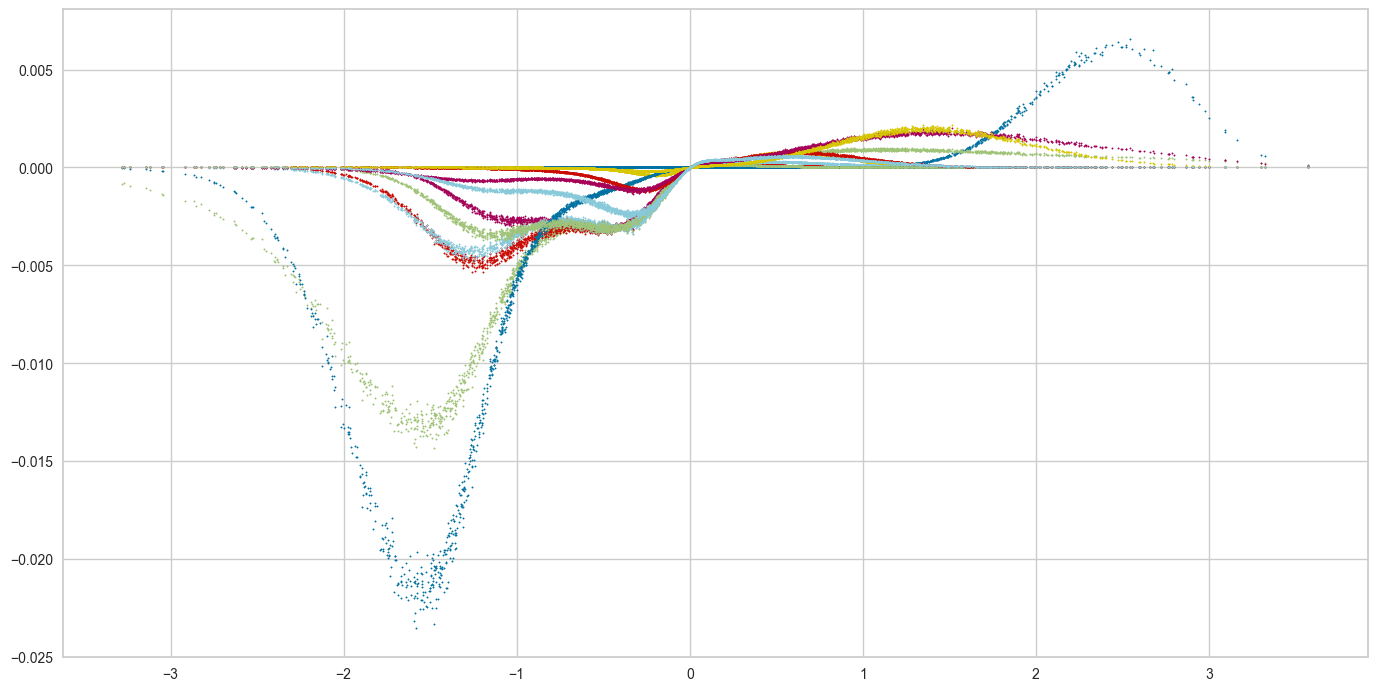

In [72]:
plt.rcParams['figure.figsize'] = 15.0, 8.0
for i in range(args["neurons_out_layer"]):
    aaa = np.array(gsnet.model.embedded(Xt)[:,19,i])[np.argsort(np.array(Xt["X20"]))]
    plt.scatter(np.sort(Xt["X20"]),aaa*gsnet_pred[:,(4+aa+bb+50+19)][np.argsort(np.array(Xt["X20"]))],s=1)
    # plt.scatter(np.sort(Xt["X10"]),aaa,s=1)

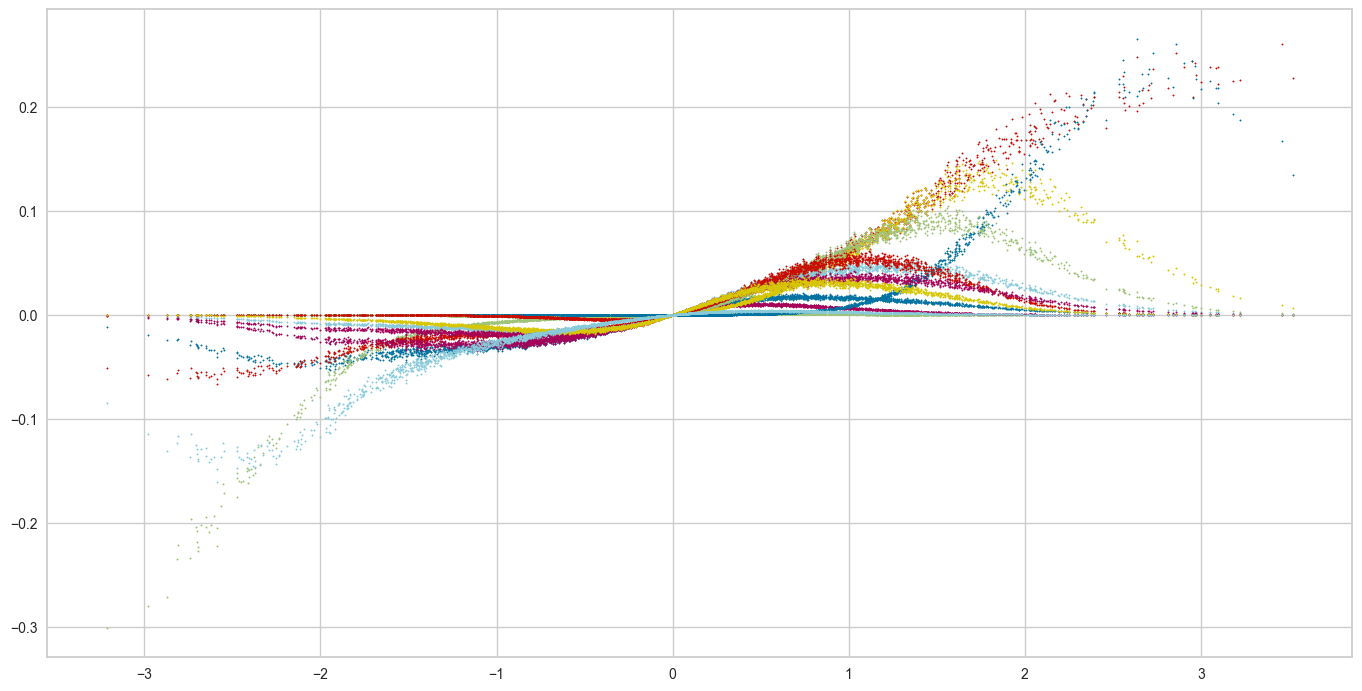

In [73]:
plt.rcParams['figure.figsize'] = 15.0, 8.0
for i in range(args["neurons_out_layer"]):
    aaa = np.array(gsnet.model.embedded(Xt)[:,2,i])[np.argsort(np.array(Xt["X3"]))]
    plt.scatter(np.sort(Xt["X3"]),aaa*gsnet_pred[:,(4+aa+bb+25+2)][np.argsort(np.array(Xt["X3"]))],s=1)
    # plt.scatter(np.sort(Xt["X3"]),aaa,s=1)

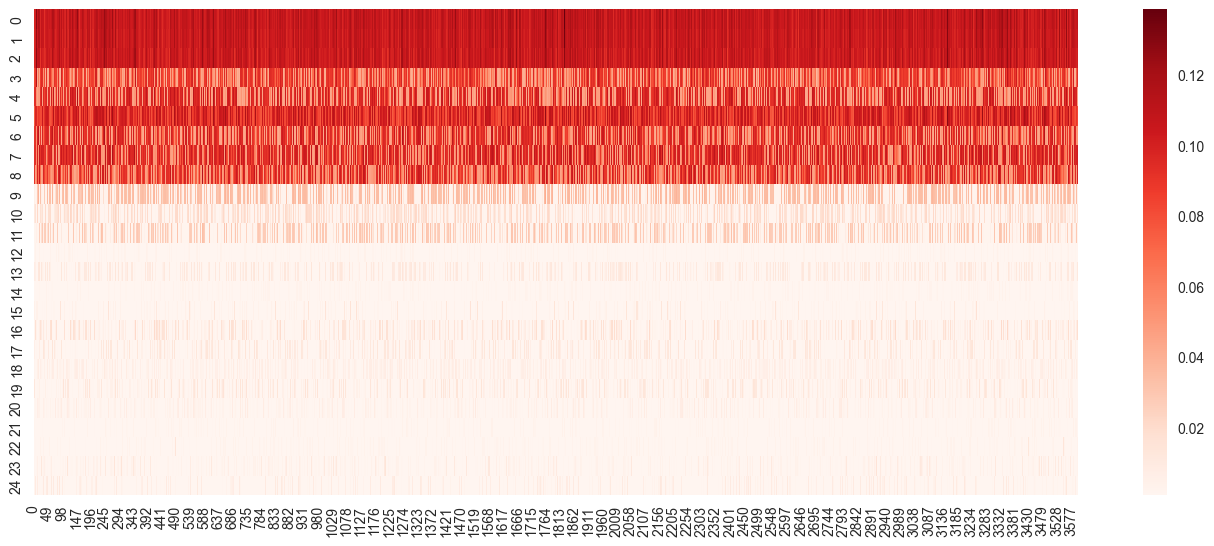

In [74]:
import seaborn as sns
all_latent_wts=pd.DataFrame(gsnet_pred[:,(4+aa+bb):(4+aa+bb+ff)]).T
plt.rcParams['figure.figsize'] = 15.0, 6.0
sns.heatmap(all_latent_wts,annot_kws={"size":1},cmap="Reds")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

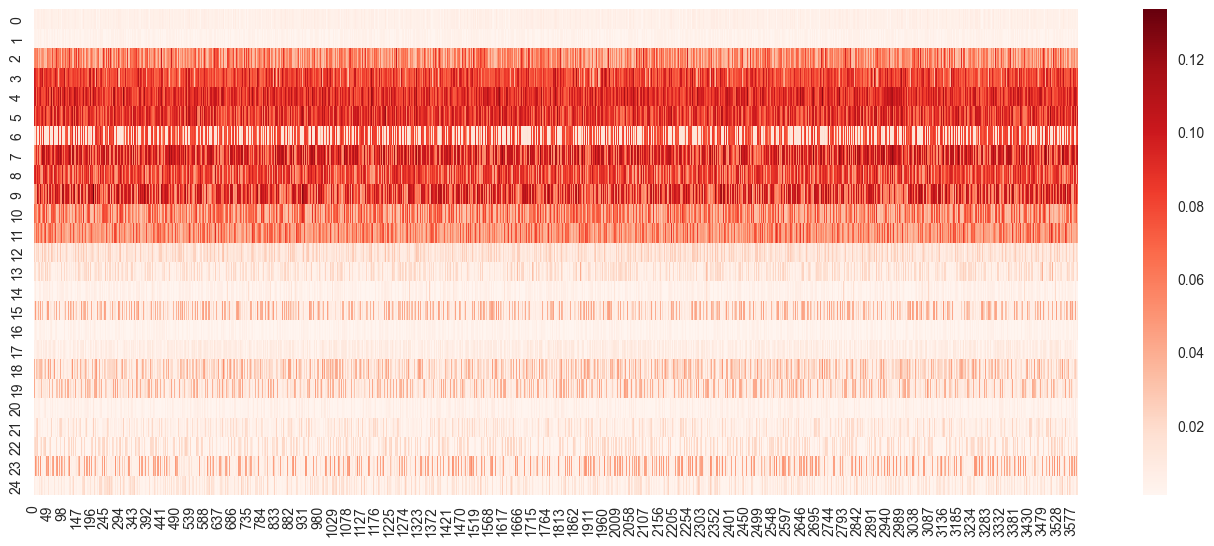

In [75]:
import seaborn as sns
all_latent_wts=pd.DataFrame(gsnet_pred[:,(4+aa+bb+ff):(4+aa+bb+2*ff)]).T
plt.rcParams['figure.figsize'] = 15.0, 6.0
sns.heatmap(all_latent_wts,annot_kws={"size":1},cmap="Reds")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

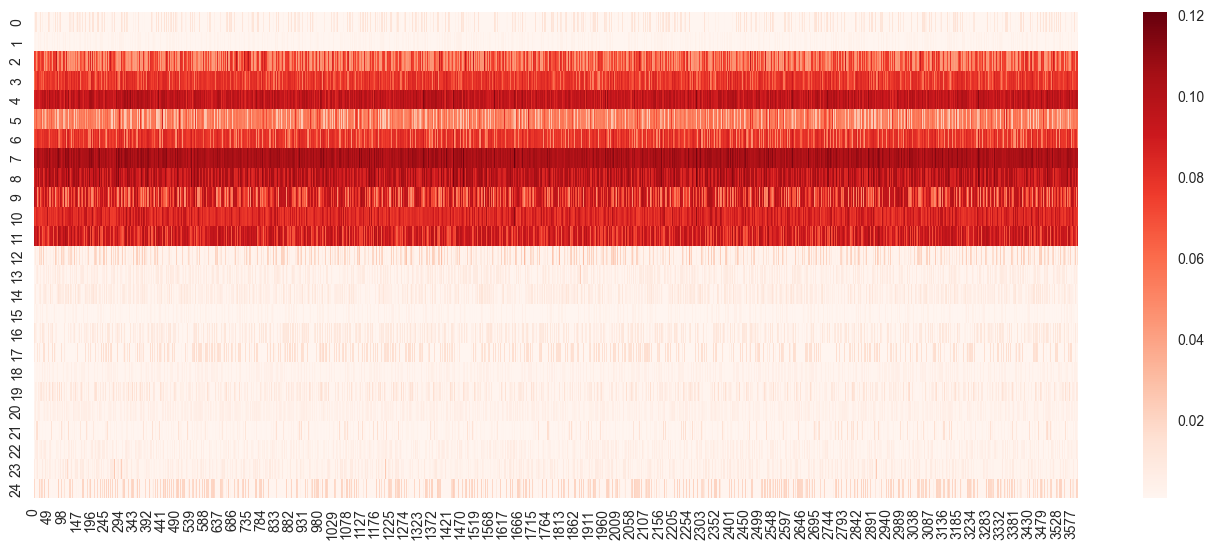

In [76]:
import seaborn as sns
all_latent_wts=pd.DataFrame(gsnet_pred[:,(4+aa+bb+2*ff):(4+aa+bb+3*ff)]).T
plt.rcParams['figure.figsize'] = 15.0, 6.0
sns.heatmap(all_latent_wts,annot_kws={"size":1},cmap="Reds")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

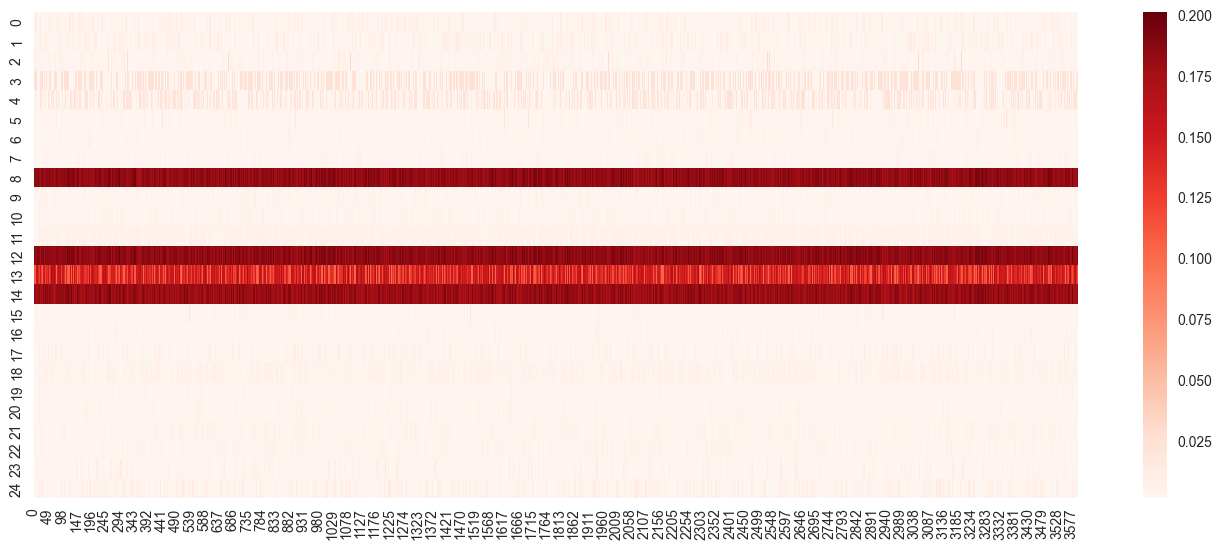

In [77]:
import seaborn as sns
all_latent_wts=pd.DataFrame(gsnet_pred[:,(4+aa+bb+3*ff):(4+aa+bb+4*ff)]).T
plt.rcParams['figure.figsize'] = 15.0, 6.0
sns.heatmap(all_latent_wts,annot_kws={"size":1},cmap="Reds")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

(-3.5, 6.5)

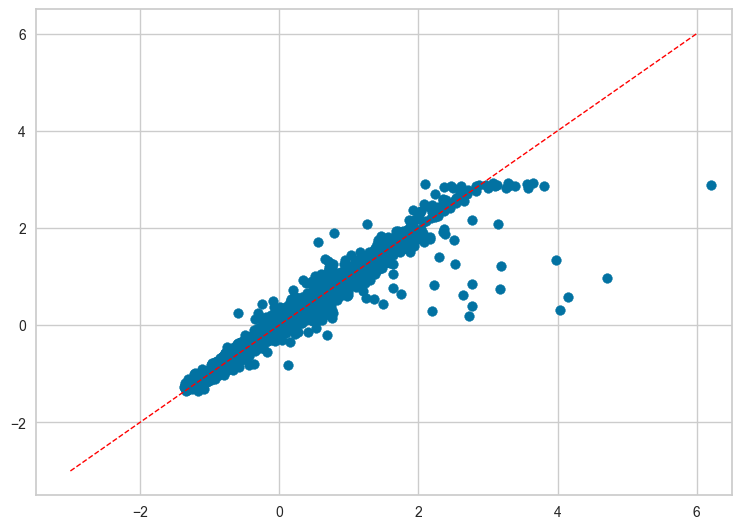

In [78]:
plt.figure(figsize=(8, 6))
plt.scatter(true_ite_test.numpy().squeeze(),gsnet_ite)
plt.plot([-3,6],[-3,6],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,6.5)
plt.ylim(-3.5,6.5)

(-3.5, 6.5)

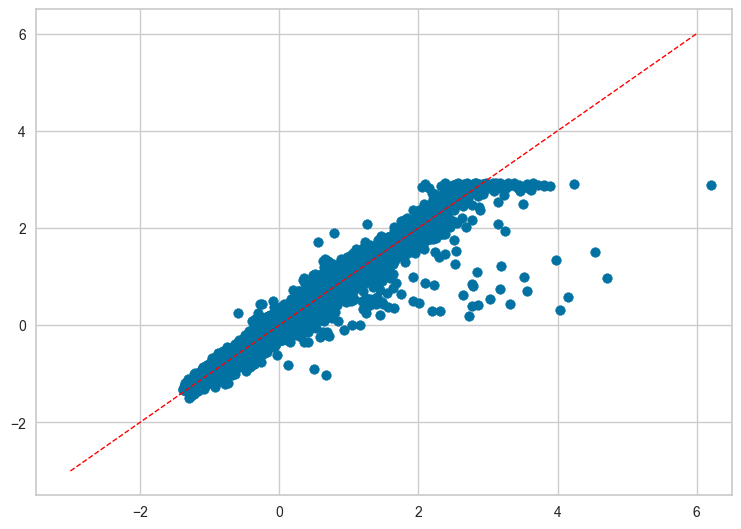

In [79]:
plt.figure(figsize=(8, 6))
plt.scatter(true_ite.numpy().squeeze(),gsnet_ite_all)
plt.plot([-3,6],[-3,6],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,6.5)
plt.ylim(-3.5,6.5)

In [80]:
#murisk_ce loss
pehe_train = np.sqrt(np.mean((true_ite_train.numpy().squeeze()-gsnet_ite_tr)**2))
pehe_test = np.sqrt(np.mean((true_ite_test.numpy().squeeze()-gsnet_ite)**2))
pehe_all = np.sqrt(np.mean((true_ite.numpy().squeeze()-gsnet_ite_all)**2))
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite.mean()}")
print(f"pred ATE:  {gsnet_ite_all.mean()}")
print(abs(true_ite.mean()-gsnet_ite_all.mean()))

Train:  0.15720827877521515
Test:  0.2123299241065979
ALL data:  0.17557138204574585
True ATE:  0.1443278193473816
pred ATE:  0.13138949871063232
tensor(0.0129)


In [27]:
#original loss
pehe_train = np.sqrt(np.mean((true_ite_train.numpy().squeeze()-gsnet_ite_tr)**2))
pehe_test = np.sqrt(np.mean((true_ite_test.numpy().squeeze()-gsnet_ite)**2))
pehe_all = np.sqrt(np.mean((true_ite.numpy().squeeze()-gsnet_ite_all)**2))
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite.mean()}")
print(f"pred ATE:  {gsnet_ite_all.mean()}")
print(abs(true_ite.mean()-gsnet_ite_all.mean()))

Train:  0.7316012978553772
Test:  0.7631382346153259
ALL data:  0.7412033677101135
True ATE:  0.1443278193473816
pred ATE:  0.2366165816783905
tensor(0.0923)


In [73]:
from sklearn.metrics import accuracy_score
a=gsnet_t_all.copy()
a[(gsnet_t_all>0.5)]=1
a[(gsnet_t_all<=0.5)]=0
a_tr=gsnet_t_tr.copy()
a_tr[(gsnet_t_tr>0.5)]=1
a_tr[(gsnet_t_tr<=0.5)]=0
a_ts=gsnet_t.copy()
a_ts[(gsnet_t>0.5)]=1
a_ts[(gsnet_t<=0.5)]=0
aa = df["Treat"]
print(f"accuracy_Train:  {accuracy_score(np.array(treatmentX),a_tr)}")
print(f"accuracy_Test:  {accuracy_score(np.array(treatmentt),a_ts)}")
print(f"accuracy_all:  {accuracy_score(np.array(aa),a)}")
print(f"CE_Train:  {log_loss(np.array(treatmentX),gsnet_t_tr)}")
print(f"CE_Test:  {log_loss(np.array(treatmentt),gsnet_t)}")
print(f"CE_all:  {log_loss(np.array(aa),gsnet_t_all)}")

accuracy_Train:  0.7404761904761905
accuracy_Test:  0.7297222222222223
accuracy_all:  0.73725
CE_Train:  0.4984135746844312
CE_Test:  0.5051817995468084
CE_all:  0.5004440405343334


In [74]:
b=gsnet_y1_all*np.array(df["Treat"])+gsnet_y0_all*(1-np.array(df["Treat"]))
b_tr=gsnet_y1_tr*np.array(treatmentX)+gsnet_y0_tr*(1-np.array(treatmentX))
b_ts=gsnet_y1*np.array(treatmentt)+gsnet_y0*(1-np.array(treatmentt))
np.sqrt(np.mean((np.array(df["outcome"])-b)**2))
bb = df["outcome"]

print(f"mse_Train:  {np.sqrt(np.mean((np.array(y_train*yss+ymm)-b_tr)**2))}")
print(f"mse_Test:  {np.sqrt(np.mean((np.array(y_test*yss+ymm)-b_ts)**2))}")
print(f"mse_all:  {np.sqrt(np.mean((np.array(bb)-b)**2))}")

mse_Train:  0.12069463729858398
mse_Test:  0.1515795886516571
mse_all:  0.13072852209415475


In [41]:
tt=treatment
gsnet_t_all=gsnet_t_all
yy0=gsnet_y0_all
yy1=gsnet_y1_all
yy_hat=yy1*tt+yy0*(1-tt)
yy=np.array(y)*ys+ym
term1=gsnet_ite_all
term2=tt/gsnet_t_all-(1-tt)/(1-gsnet_t_all)
term3=yy-yy_hat
DR_pseudo = term1+term2*term3

R_m=yy1*gsnet_t_all+yy0*(1-gsnet_t_all)
R_e=gsnet_t_all
R_Yresid=yy-R_m
R_Dresid=tt-R_e
R_pseudo=R_Yresid/R_Dresid
R_weights=R_Dresid**2

resultdata={"gsnet_ite":gsnet_ite_all,
            "pseudo outcome_DR":DR_pseudo,
            "pseudo outcome_R":R_pseudo,
            "pseudo outcome_R_w":R_weights,
            "propensity_hat":gsnet_t_all}
resultdata=pd.DataFrame(resultdata)
output=pd.concat([df.reset_index(drop=True),resultdata],axis=1)
output.to_csv("gsnet_to_metalearner_output.csv")
output

,outcome,ite,Treat,X1,X2,X3,X4,X5,X6,X7,...,X21,X22,X23,X24,X25,gsnet_ite,pseudo outcome_DR,pseudo outcome_R,pseudo outcome_R_w,propensity_hat
0,0.608289,-0.968503,0,-0.638286,0.778571,-0.025439,-0.227035,0.762376,-0.433686,-0.081588,...,0.815101,-0.734019,-0.203708,2.163823,1.231969,-0.920943,-1.326101,-1.385548,0.216994,0.465826
1,0.027236,0.671752,0,-1.129391,0.011928,1.222136,-2.386352,-0.777801,1.017212,-0.418488,...,-0.144285,0.003932,1.696536,1.903938,2.464826,0.718643,0.728086,0.737892,0.108310,0.329104
2,1.994356,-0.505744,0,1.529113,-0.324047,-0.164718,-0.290616,-1.484816,-1.179039,-1.703169,...,-1.149429,0.127326,-1.383979,-1.127948,-0.085823,-0.526902,-0.432041,0.667035,0.005418,0.073605
3,-0.538247,-0.932438,1,-0.423696,-0.299019,-0.614782,-0.162784,0.094470,-0.720391,0.304090,...,1.963394,-1.005725,0.177842,0.833812,-0.603791,-0.959864,-0.786302,-0.157793,0.031647,0.822103
4,1.510896,0.981423,1,-0.537745,-1.059055,0.011904,-0.046251,-1.225533,1.551356,-0.758501,...,0.638206,-1.216172,-0.385572,0.805907,-0.022671,0.971341,1.123353,1.085135,0.327059,0.428109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,-1.700556,0.482398,0,-1.241969,0.178361,1.169268,-2.945159,-0.423169,-1.256573,-0.209459,...,0.232130,0.012023,-1.347357,0.623794,-0.905570,0.488913,0.715255,1.002839,0.093487,0.305756
11996,-0.001834,1.058053,0,-1.416058,0.152676,0.213462,-1.673514,-0.590570,-1.985411,1.113491,...,-0.062651,0.339632,-0.368498,0.270720,1.669065,1.016656,0.947584,0.409919,0.010446,0.102206
11997,0.797086,0.882100,0,-0.191864,1.249449,-1.971868,0.697577,-0.533814,0.284072,0.316626,...,0.403530,-0.754097,-0.577671,0.850303,0.087690,0.904844,0.884934,0.765444,0.015619,0.124976
11998,0.952328,1.596319,0,0.060644,0.709974,-0.534099,-1.344388,-1.358094,0.458564,0.073742,...,-0.795406,0.467583,-0.265747,1.780124,1.307995,1.520532,1.619796,1.682380,0.144520,0.380158


In [42]:
# mu-risk-ce loss
auucdata = pd.DataFrame([gsnet_pred_all[:,1]-gsnet_pred_all[:,0],
              treatment.ravel(),
              y.ravel()],
              index=['gsnet','w','y']).T
print(f"ATE = {np.mean(gsnet_ite_all)}")
print(f"ATE_DR = {np.mean(DR_pseudo)}")
print(f"ATE_R = {sum(R_pseudo*R_weights)/sum(R_weights)}")
print(f"AUUC-DRCFR = {auuc_score(auucdata)[0]}")
print(f"AUUC-random = {auuc_score(auucdata)[1]}")

ATE = 0.14309684932231903
ATE_DR = 0.14315205812454224
ATE_R = 0.14366342717505934
AUUC-DRCFR = 1.7977716772812382
AUUC-random = 0.4972086352387455


In [48]:
XtO = Xt.copy()
XtO[["X1","X2"]]=0.0
yss = ys
ymm = ym
ys = np.array(yss)
ym = np.array(ymm)
gsnet_pred=gsnet.predict(XtO,treatmentt)
gsnet_pred0=gsnet.predict(XtO, np.zeros(len(treatmentt)))[:,0]
gsnet_pred1=gsnet.predict(XtO, np.ones(len(treatmentt)))[:,0]
gsnet_pred[:,0]=gsnet_pred0*ys+ym
gsnet_pred[:,1]=gsnet_pred1*ys+ym
gsnet_ite = np.array(gsnet_pred[:,1]-gsnet_pred[:,0])
gsnet_t = np.array(gsnet_pred[:,2])
gsnet_y1 = np.array(gsnet_pred[:,1])
gsnet_y0 = np.array(gsnet_pred[:,0])

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [49]:
print("ITE")
print(np.sqrt(np.mean((true_ite_test.numpy().squeeze()-gsnet_ite)**2)))
print("")
print("t prediction")
a_ts=gsnet_t.copy()
a_ts[(gsnet_t>0.5)]=1
a_ts[(gsnet_t<=0.5)]=0
aa = df["Treat"]
print(accuracy_score(np.array(treatmentt),a_ts))
print(log_loss(np.array(treatmentt),gsnet_t))
print("")
print("y prediction")
b_ts=gsnet_y1*np.array(treatmentt)+gsnet_y0*(1-np.array(treatmentt))
bb = df["outcome"]
print(np.sqrt(np.mean((np.array(y_test*yss+ymm)-b_ts)**2)))

ITE
0.10891329

t prediction
0.7052777777777778
0.5591483124583704

y prediction
0.13914578


In [43]:
# tt=t_test.numpy().squeeze()
# dr_cfr_t=dr_cfr_t
# yy0=dr_cfr_y0
# yy1=dr_cfr_y1
# yy_hat=yy1*tt+yy0*(1-tt)
# yy=np.array(y_test)
# term1=dr_cfr_ite
# term2=tt/dr_cfr_t-(1-tt)/(1-dr_cfr_t)
# term3=yy-yy_hat
# DR_pseudo = term1+term2*term3

# R_m=yy1*dr_cfr_t+yy0*(1-dr_cfr_t)
# R_e=dr_cfr_t
# R_Yresid=yy-R_m
# R_Dresid=tt-R_e
# R_pseudo=R_Yresid/R_Dresid
# R_weights=R_Dresid**2

# resultdata_test={"drcfr_ite":dr_cfr_ite,
#             "pseudo outcome_DR":DR_pseudo,
#             "pseudo outcome_R":R_pseudo,
#             "pseudo outcome_R_w":R_weights,
#             "propensity_hat":dr_cfr_t}
# resultdata_test=pd.DataFrame(resultdata_test)
# output_test=pd.concat([df_test.reset_index(drop=True),resultdata_test],axis=1)
# output_test.to_csv("drcfr_to_metalearner_output_test.csv")

--------------------------------------------------------------------------------------------------------------------------------------------------------

In [56]:
x_name = df_test.columns
x_name = x_name.drop(["outcome","ite","Treat"])
datax = pd.DataFrame(x_test)
datax.columns = x_name

from pycaret.classification import *
model_e = load_model("15000data_nuisance_e")
nuisance_e = predict_model(model_e, data=datax)
nuisance_e["prediction_score"] = nuisance_e["prediction_score"]*nuisance_e["prediction_label"]+(1-nuisance_e["prediction_score"])*(1-nuisance_e["prediction_label"])
nuisance_e = np.array(nuisance_e["prediction_score"])

from pycaret.regression import *
model_m = load_model("15000data_nuisance_m")
nuisance_m = predict_model(model_m, data=datax)
nuisance_m = np.array(nuisance_m["prediction_label"])

from pycaret.regression import *
model_m1 = load_model("15000data_nuisance_m1")
nuisance_m1 = predict_model(model_m1, data=datax)
nuisance_m1 = np.array(nuisance_m1["prediction_label"])

from pycaret.regression import *
model_m0 = load_model("15000data_nuisance_m0")
nuisance_m0 = predict_model(model_m0, data=datax)
nuisance_m0 = np.array(nuisance_m0["prediction_label"])

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


(-3.5, 8.0)

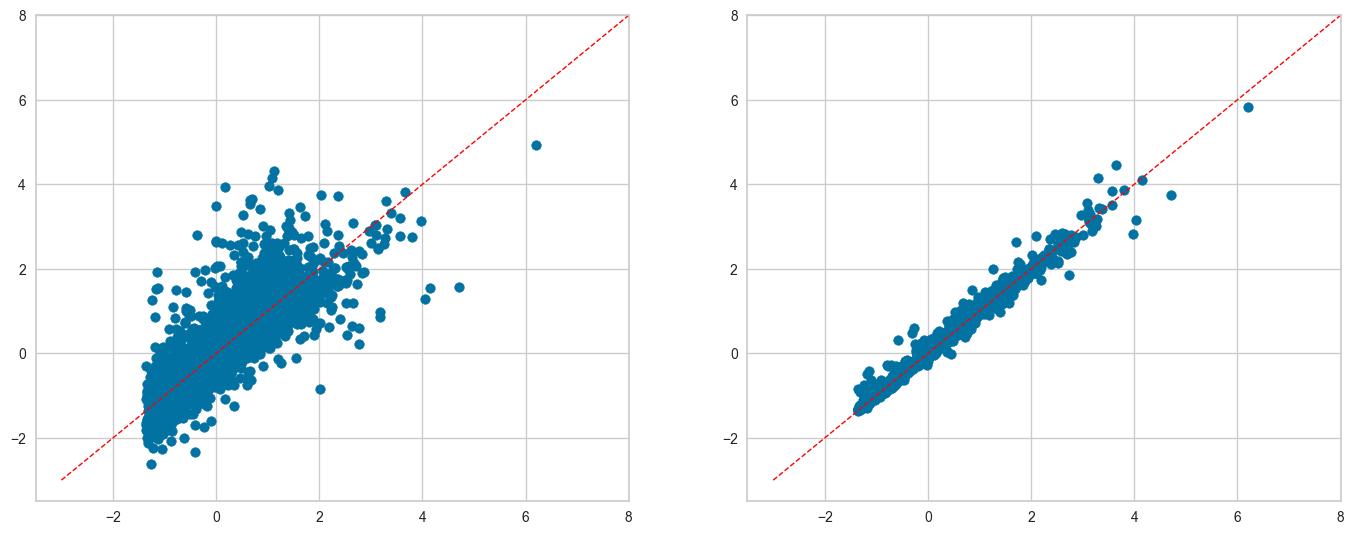

In [57]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.scatter(true_ite_test.numpy().squeeze(),(nuisance_m1-nuisance_m0)*np.array(ys))
plt.plot([-3,8],[-3,8],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,8)
plt.ylim(-3.5,8)
plt.subplot(1,2,2)
plt.scatter(true_ite_test.numpy().squeeze(),gsnet_ite)
plt.plot([-3,8],[-3,8],color="red",linestyle="--",linewidth=1)
plt.xlim(-3.5,8)
plt.ylim(-3.5,8)

In [58]:
print("pehe")
print("nuisance pehe")
print(np.sqrt(np.mean((true_ite_test.numpy().squeeze()-(nuisance_m1-nuisance_m0)*np.array(ys))**2)))
print("SNet_yc pehe")
print(np.sqrt(np.mean((true_ite_test.numpy().squeeze()-gsnet_ite)**2)))

pehe
nuisance pehe
0.564957967642977
SNet_yc pehe
0.09434881


In [59]:
print("ATE")
print("nuisance pehe")
print(np.abs(np.mean((true_ite_test.numpy().squeeze()-(nuisance_m1-nuisance_m0)*np.array(ys)))))
print("SNet_yc pehe")
print(np.abs(np.mean((true_ite_test.numpy().squeeze()-gsnet_ite))))

ATE
nuisance pehe
0.08225325043586136
SNet_yc pehe
0.016220905


In [60]:
np.quantile(gsnet_ite-true_ite_test.numpy().squeeze(),q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

array([-1.14917994e+00, -5.24549853e-02, -2.82441497e-02, -1.40425913e-02,
       -7.99655914e-04,  1.08252466e-02,  2.23594308e-02,  3.56837451e-02,
        5.24918199e-02,  8.31758998e-02,  9.15356159e-01])

In [61]:
np.quantile((nuisance_m1-nuisance_m0)*np.array(ys)-true_ite_test.numpy().squeeze(),q=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1])

array([-3.13756247, -0.49567594, -0.31542311, -0.17781707, -0.07327887,
        0.03357606,  0.14020226,  0.26404432,  0.43959568,  0.72522343,
        3.75638875])

In [62]:
np.sqrt(np.mean((np.array(y_test)-(nuisance_m1*np.array(t_test)+nuisance_m0*(1-np.array(t_test))))**2))*np.array(ys)

0.3868390998152764